# Optimisation de Tournées de Convoyeurs de Fonds
## Capacitated Vehicle Routing Problem with Forbidden Edges (CVRP-FE)

---

**Titre :** Projet de Recherche Opérationnelle — A3  
**Date :** Avril 2026
**Auteurs** :
- Nom Prenom  
- Nom Prenom  
- Nom Prenom  
- Nom Prenom  

### Sommaire
1. 
2. 
3. 
4. 

---

### Le Problème Métier

Une société de transport de fonds doit organiser quotidiennement la
**collecte d'argent** dans un ensemble d'agences bancaires réparties
sur un territoire. Plusieurs **camions blindés** partent chaque matin
d'un **dépôt central** (le siège), visitent un sous-ensemble d'agences,
récupèrent les fonds, puis reviennent au dépôt.

**Enjeux :**
- Minimiser les **distances parcourues** (coûts de carburant et d'usure).
- Respecter la **capacité de stockage** de chaque camion.
- Éviter les **routes dangereuses** ou en travaux.
- Garantir que **chaque agence** est visitée au moins une fois.

---
# 1. Modélisation Formelle et Complexité Théorique

## 1.1 Définition du problème

Nous modélisons ce problème comme un **Capacitated Vehicle Routing Problem
with Forbidden Edges (CVRP-FE)**, une variante du CVRP classique où
certaines arêtes du graphe sont interdites.

### Données du problème

Le réseau routier est représenté par un graphe pondéré $G = (V, E)$ :

| Notation | Description |
|----------|-------------|
| $V = \{0, 1, \dots, n\}$ | Ensemble des sommets : $0$ = dépôt central, $\{1, \dots, n\}$ = agences bancaires |
| $N = \{1, 2, \dots, n\}$ | Ensemble des villes (agences) à visiter |
| $E \subseteq V \times V$ | Ensemble des arêtes (routes existantes) |
| $F \subset E$ | Ensemble des **arêtes interdites** (routes coupées ou dangereuses) A VOIR SI ON MET DANS F AVEC LA GOAT |
| $E' = E \setminus F$ | Ensemble des arêtes **utilisables** |
| $d_{ij}$ | Distance associée à l'arête $(i, j) \in E$ |
| $K = \{1, 2, \dots, k\}$ | Ensemble des camions blindés identiques |
| $Q$ | Capacité maximale de stockage d'un camion (en €) |
| $q_i$ | Montant d'argent à collecter à l'agence $i$ ($q_0 = 0$ pour le dépôt) |
| $u_i, u_j$ | Le niveau de remplissage du camion aux points $i$ et $j$ |

## 1.2 Variables de décision

$$x_{ij}^{k} = \begin{cases} 1 & \text{si le camion } k \text{ emprunte la route } (i,j) \\ 0 & \text{sinon} \end{cases} \quad \forall\, (i,j) \in E', \; \forall\, k \in K$$

$$u_i \geq 0 \quad \text{charge cumulée du camion lors de la visite du sommet } i$$

> **Note :** Les variables $u_i$ (dites de *Miller-Tucker-Zemlin*) servent
> à la fois à tracer la charge cumulée et à éliminer les sous-tours.

## 1.3 Fonction objectif

Minimiser la distance totale parcourue par l'ensemble de la flotte :

$$\min \sum_{k \in K} \sum_{(i,j) \in E'} d_{ij} \cdot x_{ij}^{k}$$

## 1.4 Contraintes

**C1 — Visite obligatoire :** Chaque agence doit être visitée au moins
une fois par exactement un camion.

$$\sum_{k \in K} \sum_{j \in V : (i,j) \in E'} x_{ij}^{k} = 1 \quad \forall\, i \in N$$

**C2 — Conservation du flux (continuité du trajet) :** Un camion qui
arrive dans une ville doit obligatoirement en repartir.

$$\sum_{j \in V : (j,i) \in E'} x_{ji}^{k} = \sum_{j \in V : (i,j) \in E'} x_{ij}^{k} \quad \forall\, i \in V, \; \forall\, k \in K$$

**C3 — Départ et retour au dépôt :** Chaque camion part du dépôt et y
revient.

$$\sum_{j \in N : (0,j) \in E'} x_{0j}^{k} \leq 1, \quad \sum_{j \in N : (j,0) \in E'} x_{j0}^{k} \leq 1 \quad \forall\, k \in K$$

**C4 — Respect de la capacité (plafond de collecte) :** La somme des
montants collectés sur une tournée ne dépasse pas la capacité $Q$.

$$\sum_{i \in N} q_i \cdot \sum_{j \in V : (i,j) \in E'} x_{ij}^{k} \leq Q \quad \forall\, k \in K$$

**C5 — Interdiction des routes à éviter :** Les arêtes appartenant à
l'ensemble $F$ sont strictement interdites.

$$x_{ij}^{k} = 0 \quad \forall\, (i,j) \in F, \; \forall\, k \in K$$

> En pratique, cette contrainte est implémentée en **supprimant** les arêtes
> de $F$ du graphe ou en leur attribuant un coût $+\infty$.

## 1.5 Complexité Théorique

### Le CVRP-FE est NP-Difficile

**Théorème :** Le CVRP avec arêtes interdites est NP-difficile.

**Preuve (par réduction depuis le TSP) :**

1. Le **Problème du Voyageur de Commerce (TSP)** est NP-difficile
   (Karp, 1972 [1]).
2. Toute instance du TSP sur $n$ villes peut être réduite en temps
   polynomial à une instance du CVRP-FE en posant :
   - $|K| = 1$ (un seul véhicule),
   - $Q = +\infty$ (capacité infinie),
   - $F = \emptyset$ (aucune arête interdite).
3. La solution optimale du CVRP-FE ainsi construit correspond exactement
   à la solution optimale du TSP.
4. Si le CVRP-FE admettait un algorithme polynomial, on pourrait résoudre
   le TSP en temps polynomial, ce qui contredirait l'hypothèse $P \neq NP$.

Par conséquent, $\text{TSP} \leq_p \text{CVRP-FE}$, et le CVRP-FE est
**NP-difficile**. $\blacksquare$

> **Remarque :** L'ajout des arêtes interdites rend le problème encore
> plus complexe en pratique, car il réduit l'espace des solutions
> réalisables et peut fragmenter le graphe.

### Références bibliographiques

1. **Dantzig, G. B. & Ramser, J. H.** (1959). *The Truck Dispatching
   Problem*. Management Science, 6(1), 80–91. — Article fondateur du VRP.
2. **Toth, P. & Vigo, D.** (2002). *The Vehicle Routing Problem*. SIAM
   Monographs on Discrete Mathematics and Applications. — Ouvrage de
   référence exhaustif.
3. **Karp, R. M.** (1972). *Reducibility Among Combinatorial Problems*.
   Complexity of Computer Computations, pp. 85–103. — Preuve de
   NP-complétude du TSP.
4. **Clarke, G. & Wright, J. W.** (1964). *Scheduling of Vehicles from a
   Central Depot to a Number of Delivery Points*. Operations Research,
   12(4), 568–581. — Heuristique d'épargne (Savings algorithm).
5. **Kirkpatrick, S., Gelatt, C. D. & Vecchi, M. P.** (1983). *Optimization
   by Simulated Annealing*. Science, 220(4598), 671–680.

---
# 2. Générateur d'Instances Aléatoires

On construit un générateur d'instances qui simule un territoire
d'intervention réaliste pour les convoyeurs de fonds :

- **Coordonnées 2D** aléatoires → calcul de distances euclidiennes.
- **Montants d'argent** aléatoires par agence.
- **Routes interdites** générées aléatoirement (paires de villes).
- **Vérification de connexité** : on s'assure que le graphe reste
  connexe malgré les suppressions pour garantir l'existence d'une
  solution réalisable.
- **Vérification de faisabilité** : la capacité cumulée des camions
  est suffisante pour couvrir la demande totale.

---
# 2. Imports & Configuration

In [43]:
import math
import random
import time
import copy
import warnings
from dataclasses import dataclass, field
from typing import List, Tuple, Set, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches

import json
import networkx as nx

import pulp
import pandas as pd



In [44]:

warnings.filterwarnings("ignore")

# Configuration globale de matplotlib pour des graphiques de qualité
plt.rcParams.update({
    "figure.figsize": (12, 8),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "serif",
    "axes.facecolor": "#FAFAFA",
})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

---
# 3. Générateur d'instances

Fonctions utilitaires pour créer les instances VRP.

In [69]:
def generate_synthetic_cities(N, x_max=100, y_max=100):
    """
    Generates a list of N cities with random (x, y) coordinates.
    Index 0 is always considered the Dépôt.
    """
    cities = []
    
    for i in range(N):
        city = {
            'id': i,
            'nom': f"Dépôt" if i == 0 else f"Ville_{i}",
            'x': round(random.uniform(0, x_max), 2),
            'y': round(random.uniform(0, y_max), 2)
        }
        cities.append(city)
        
    return cities

In [46]:
VILLE_SAMPLE = generate_synthetic_cities(10000, 1000, 1000)

In [47]:
# ==========================================
# 1. CHARGEMENT DU FICHIER JSON
# ==========================================
try:
    with open('villes.json', 'r', encoding='utf-8') as fichier:
        VILLES_SOURCE = json.load(fichier)
    print(f"✅ {len(VILLES_SOURCE)} villes chargées avec succès depuis 'villes.json'.")
except FileNotFoundError:
    print("❌ Erreur : Le fichier 'villes.json' est introuvable.")
    print("Vérifiez qu'il est bien enregistré dans le même dossier que ce Notebook.")
    VILLES_SOURCE = [] # Liste vide pour éviter de faire planter la suite

✅ 100 villes chargées avec succès depuis 'villes.json'.


In [48]:
def create_vrp_city_network(N, X=None, blocking_rate=0.1, city_list=None):
    """
    Creates a connected graph.
    X: total number of routes (defaults to N*3).
    blocking_rate: percentage (0.0 to 1.0) of routes with an INF weight.
    """
    INF = 1e9
    if X is None:
        X = N * 3
    
    max_possible_routes = (N * (N - 1)) // 2
    X = min(X, max_possible_routes)

    selected_cities = random.sample(city_list, N)
    weight_matrix = np.full((N, N), None) 

    all_distances = []
    for i in range(N):
        for j in range(i + 1, N):
            v1, v2 = selected_cities[i], selected_cities[j]
            dist = np.sqrt((v2['x'] - v1['x'])**2 + (v2['y'] - v1['y'])**2)
            all_distances.append((dist, i, j))
    
    all_distances.sort(key=lambda x: x[0])

    final_routes = []
    parent = list(range(N))
    def find(i):
        if parent[i] == i: return i
        return find(parent[i])

    def union(i, j):
        root_i, root_j = find(i), find(j)
        if root_i != root_j:
            parent[root_i] = root_j
            return True
        return False

    # Ensure connectivity (MST)
    for dist, i, j in all_distances:
        if union(i, j):
            final_routes.append((dist, i, j))
        if len(final_routes) == N - 1:
            break

    # Add extra routes until X is reached
    for d, i, j in all_distances:
        if len(final_routes) >= X:
            break
        if not any((i == r[1] and j == r[2]) for r in final_routes):
            final_routes.append((d, i, j))

    # Apply blocked routes
    blocked_count = int(len(final_routes) * blocking_rate)
    blocked_indices = random.sample(range(len(final_routes)), blocked_count)
    
    for idx, (dist, i, j) in enumerate(final_routes):
        weight = INF if idx in blocked_indices else dist
        weight_matrix[i][j] = weight
        weight_matrix[j][i] = weight
        
    return selected_cities, weight_matrix

In [49]:
def assign_city_data(cities, nb_to_visit=None, demand_range=(40, 100)):
    """
    Assigns a demand to exactly 'nb_to_visit' agencies.
    The depot (index 0) always remains at 0.
    """
    N = len(cities)
    if nb_to_visit == None :
        nb_to_visit = int(N * 0.25)
    nb_to_visit = min(nb_to_visit, N - 1)
    
    demands = {i: 0 for i in range(N)}
    
    collection_indices = random.sample(range(1, N), nb_to_visit)
    
    for idx in collection_indices:
        demands[idx] = random.randint(demand_range[0], demand_range[1])
            
    return list(demands.items())

---
# 4. Fonctions de visualisation

In [50]:
def display_vrp_chart(cities_N, weight_matrix, cities_data, prob=None, x=None, K=None):
    """
    Displays the VRP network. 
    If prob, x, and K are provided, also displays the optimized truck routes.
    """
    NUMBER_OF_CITIES_N = len(cities_N)
    INF_THRESHOLD = 1e8

    # --- 1. Preparation of Roles ---
    collection_pts = [idx for idx, q_i in cities_data if q_i > 0 and idx != 0]
    transit_pts = [idx for idx, q_i in cities_data if q_i == 0 and idx != 0]
    q = {idx: q_i for idx, q_i in cities_data}

    # --- 2. Graph Construction ---
    G = nx.DiGraph() # DiGraph for route arrows
    pos = {i: (v['x'], v['y']) for i, v in enumerate(cities_N)}
    city_names = {i: v['nom'] for i, v in enumerate(cities_N)}
    
    active_routes = []
    blocked_routes = []
    weight_labels = {}

    for i in range(NUMBER_OF_CITIES_N):
        for j in range(NUMBER_OF_CITIES_N):
            if i != j:
                p = weight_matrix[i][j]
                if p is not None:
                    if p >= INF_THRESHOLD:
                        if i < j: blocked_routes.append((i, j))
                    else:
                        if i < j: 
                            active_routes.append((i, j))
                            weight_labels[(i, j)] = f"{float(p):.1f}"

    # --- 3. Visualization ---
    plt.figure(figsize=(16, 11))

    # A. Nodes: DEPOT, COLLECTION, TRANSIT
    nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='#f39c12', 
                           node_size=1100, edgecolors='black', linewidths=2)
    nx.draw_networkx_nodes(G, pos, nodelist=collection_pts, node_color='#2ecc71', 
                           node_size=800, edgecolors='black', alpha=0.9)
    nx.draw_networkx_nodes(G, pos, nodelist=transit_pts, node_color='#bdc3c7', 
                           node_size=600, edgecolors='black', alpha=0.7)

    # B. Base edges: BLOCKED and ACTIVE
    nx.draw_networkx_edges(G, pos, edgelist=blocked_routes, edge_color='#e74c3c', 
                           width=3, style='--', alpha=0.4)
    nx.draw_networkx_edges(G, pos, edgelist=active_routes, edge_color='#2c3e50', 
                           width=1.5, alpha=0.2) # Subtle to let truck routes show through

    # C. TRUCK ROUTES (If solver has finished)
    truck_colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c']
    route_handles = []
    
    if prob and x and K and prob.status == 1:
        for k in K:
            segments = [(i, j) for i in range(NUMBER_OF_CITIES_N) for j in range(NUMBER_OF_CITIES_N)
                        if value(x[k][i][j]) is not None and value(x[k][i][j]) > 0.9]
            if segments:
                color = truck_colors[k % len(truck_colors)]
                nx.draw_networkx_edges(G, pos, edgelist=segments, edge_color=color, 
                                       width=4, arrowstyle='-|>', arrowsize=20)
                route_handles.append(mpatches.Patch(color=color, label=f'Trajet Camion {k}'))

    # D. Labels: Cities and Weights
    city_labels = {idx: f"{city_names[idx]}\n({q_i}€)" if q_i > 0 else city_names[idx] 
                     for idx, q_i in cities_data}
    
    label_pos = {i: (coords[0], coords[1] + 0.4) for i, coords in pos.items()}
    nx.draw_networkx_labels(G, label_pos, labels=city_labels, font_size=9, font_weight='bold',
                            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, boxstyle='round,pad=0.2'))

    nx.draw_networkx_edge_labels(G, pos, edge_labels=weight_labels, font_size=7, 
                                 font_color='#2980b9', font_weight='bold', alpha=0.5)

    # E. Title and Legend
    status_str = " (Résultat Optimisé)" if (prob and prob.status == 1) else " (Carte Initiale)"
    plt.title(f"Visualisation VRP{status_str} : {len(collection_pts)} Agences", fontsize=15, pad=20)
    
    base_legend = [
        mpatches.Patch(color='#f39c12', label='Dépôt (0)'),
        mpatches.Patch(color='#2ecc71', label='Collecte (q_i > 0)'),
        mpatches.Patch(color='#bdc3c7', label='Transit (q_i = 0)'),
        mpatches.Patch(color='#2c3e50', label='Route Active'),
        mpatches.Patch(color='#e74c3c', label='Route Bloquée (∞)', linestyle='--')
    ]
    
    plt.legend(handles=base_legend + route_handles, loc='upper left', fontsize=9, frameon=True)

    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [68]:
def visualize_final_vrp(cities_N, weight_matrix, cities_data, routes, title="Solution VRP", real_dist=None):
    """
    Universal function to display any VRP solution.
    'routes' must be a list of index lists: [[0, 1, 2, 0], [0, 3, 0], ...]
    """
    NUMBER_OF_CITIES_N = len(cities_N)
    INF_THRESHOLD = 1e8

    # --- 1. Data Preparation ---
    collection_pts = [idx for idx, q_i in cities_data if q_i > 0 and idx != 0]
    transit_pts = [idx for idx, q_i in cities_data if q_i == 0 and idx != 0]
    q = {idx: q_i for idx, q_i in cities_data}
    
    # Coordinates and names
    pos = {i: (v['x'], v['y']) for i, v in enumerate(cities_N)}
    city_names = {i: v['nom'] for i, v in enumerate(cities_N)}

    # --- 2. Base Graph Construction (Infrastructure) ---
    G = nx.DiGraph()
    active_routes = []
    blocked_routes = []
    weight_labels = {}

    for i in range(NUMBER_OF_CITIES_N):
        for j in range(i + 1, NUMBER_OF_CITIES_N):
            p = weight_matrix[i][j]
            if p is not None:
                if p >= INF_THRESHOLD:
                    blocked_routes.append((i, j))
                else:
                    active_routes.append((i, j))
                    weight_labels[(i, j)] = f"{float(p):.1f}"

    # --- 3. Chart Drawing ---
    plt.figure(figsize=(16, 11))

    # A. Nodes: DEPOT, COLLECTION, TRANSIT
    nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='#f39c12', 
                           node_size=1100, edgecolors='black', linewidths=2)
    nx.draw_networkx_nodes(G, pos, nodelist=collection_pts, node_color='#2ecc71', 
                           node_size=800, edgecolors='black', alpha=0.9)
    nx.draw_networkx_nodes(G, pos, nodelist=transit_pts, node_color='#bdc3c7', 
                           node_size=600, edgecolors='black', alpha=0.7)

    # B. Infrastructure Edges (Gray and Red)
    nx.draw_networkx_edges(G, pos, edgelist=blocked_routes, edge_color='#e74c3c', 
                           width=2, style='--', alpha=0.4)
    nx.draw_networkx_edges(G, pos, edgelist=active_routes, edge_color='#2c3e50', 
                           width=1, alpha=0.15)

    # C. TRUCK ROUTES (The routes passed as parameters)
    truck_colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c', '#d35400', '#27ae60']
    route_handles = []
    
    # Pre-calculate real_dist if not provided
    if real_dist is None:
        V = list(range(len(cities_N)))
        real_dist, _ = calculate_all_paths(V, weight_matrix)

    total_distance = 0
    for k, route in enumerate(routes):
        # Create segments (i, j) from the list [0, 5, 3, 0]
        segments = [(route[i], route[i+1]) for i in range(len(route)-1)]

        # Calculate distance via real_dist (Floyd-Warshall) — consistent with calculate_total_distance
        route_dist = sum(real_dist[route[i]][route[i+1]] for i in range(len(route)-1))
        if route_dist >= 1e8:
            route_dist = 0  # invalid route, ignore
        total_distance += route_dist
        
        if segments:
            color = truck_colors[k % len(truck_colors)]
            nx.draw_networkx_edges(G, pos, edgelist=segments, edge_color=color, 
                                   width=4, arrowstyle='-|>', arrowsize=25)
            route_handles.append(mpatches.Patch(color=color, label=f'Camion {k+1} ({route_dist:.1f} km)'))

    # D. Labels: Cities and Weights
    city_labels = {idx: f"{city_names[idx]}\n({q_i}€)" if q_i > 0 else city_names[idx] 
                     for idx, q_i in cities_data}
    
    label_pos = {i: (coords[0], coords[1] + 0.5) for i, coords in pos.items()}
    nx.draw_networkx_labels(G, label_pos, labels=city_labels, font_size=9, font_weight='bold',
                            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

    # E. Title and Legend
    plt.title(f"{title}\nDistance Totale : {total_distance:.2f} km | {len(routes)} Camions", fontsize=16, pad=20)
    
    base_legend = [
        mpatches.Patch(color='#f39c12', label='Dépôt (0)'),
        mpatches.Patch(color='#2ecc71', label='Collecte (q_i > 0)'),
        mpatches.Patch(color='#bdc3c7', label='Transit (q_i = 0)'),
        mpatches.Patch(color='#e74c3c', label='Route Bloquée (∞)', linestyle='--')
    ]
    
    plt.legend(handles=base_legend + route_handles, loc='upper left', fontsize=9, frameon=True, shadow=True)

    plt.axis('off')
    plt.tight_layout()
    plt.show()

---
# 5. Solveur Exact — Programmation Linéaire (PuLP)

Résolution exacte du CVRP sur petites instances (N ≤ 20) via un modèle ILP.
Sert de référence de qualité pour les heuristiques.

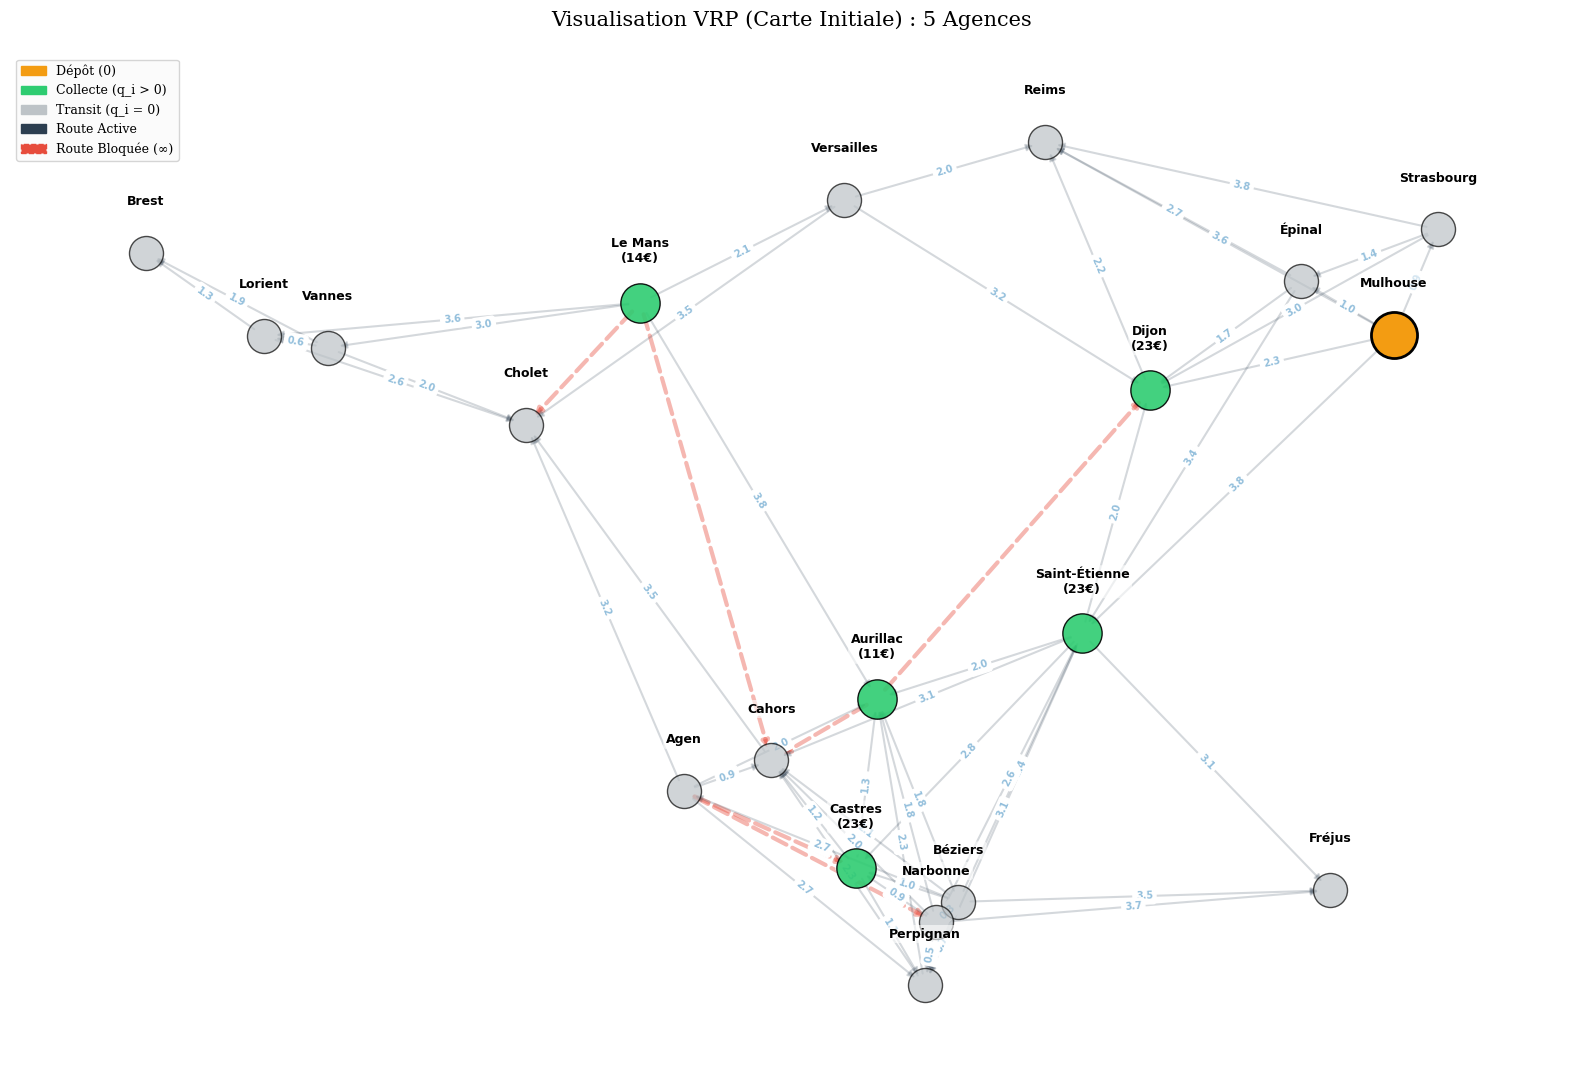

In [52]:
# ==========================================
# 1. GÉNÉRATION DES DONNÉES (Utilise tes fonctions)
# ==========================================
cities_N, weight_matrix = create_vrp_city_network(20, city_list=VILLES_SOURCE)
cities_data = assign_city_data(villes_N, demand_range=(10,25))

display_vrp_chart(villes_N, matrice_poids, villes_data)

V = [idx for idx, q_i in cities_data] 
N = [idx for idx, q_i in cities_data if q_i > 0 and idx != 0]
K = range(5) 
Q = 100
q = {idx: q_i for idx, q_i in cities_data} 

E_prime = []
F = []
for i in V:
    for j in V:
        if i != j and weight_matrix[i][j] is not None:
            if weight_matrix[i][j] < 1e8:
                E_prime.append((i, j))
            else:
                F.append((i, j))


In [53]:
from pulp import *
# ==========================================
# 2. PROBLEM CREATION ("Course" Structure)
# ==========================================
prob = LpProblem("CVRP_Final_Conveyor", LpMinimize)

x = LpVariable.dicts("x", (K, V, V), cat=LpBinary)
u = LpVariable.dicts("u", V, lowBound=0, upBound=Q, cat=LpContinuous)

prob += lpSum(weight_matrix[i][j] * x[k][i][j] for k in K for (i, j) in E_prime if weight_matrix[i][j] is not None)

In [54]:
# ==========================================
# 3. CONSTRAINTS (1.4)
# ==========================================

# C1 — Mandatory visit: Each agency in N visited once
for i in N:
    prob += lpSum(x[k][i][j] for k in K for j in V if (i, j) in E_prime) == 1

# C2 — Flow conservation: What enters must leave
for k in K:
    for i in V:
        prob += lpSum(x[k][j][i] for j in V if (j, i) in E_prime) == \
                lpSum(x[k][i][j] for j in V if (i, j) in E_prime)

# C3 — Departure and return to depot (0)
for k in K:
    prob += lpSum(x[k][0][j] for j in V if (0, j) in E_prime) <= 1
    prob += lpSum(x[k][j][0] for j in V if (j, 0) in E_prime) <= 1

# C4 — Capacity Q compliance
for k in K:
    prob += lpSum(q[i] * lpSum(x[k][i][j] for j in V if (i, j) in E_prime) for i in N) <= Q

# C5 — Sub-tour elimination (MTZ)
for k in K:
    for i in V:
        for j in V:
            if i != 0 and j != 0 and i != j and (i, j) in E_prime:
                # The max(1, q[j]) forces the return to depot even if collection=0
                prob += u[i] - u[j] + Q * x[k][i][j] <= Q - max(1, q[j])

# C6 — Prohibition of routes (Set F)
for (i, j) in F:
    for k in K:
        prob += x[k][i][j] == 0

In [55]:
# ==========================================
# 4. SOLVING AND DISPLAY
# ==========================================
# Limit to 60s to get a quick result
prob.solve(PULP_CBC_CMD(msg=1, gapRel=0.05))

print(f"Statut final : {LpStatus[prob.status]}")
if value(prob.objective):
    print(f"Distance totale optimisée : {value(prob.objective):.2f} km")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/clement/test/venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/4e6c5f85ba7c432fb977440670c30db8-pulp.mps -ratio 0.05 -timeMode elapsed -branch -printingOptions all -solution /tmp/4e6c5f85ba7c432fb977440670c30db8-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 665 COLUMNS
At line 5366 RHS
At line 6027 BOUNDS
At line 6647 ENDATA
Problem MODEL has 660 rows, 619 columns and 2960 elements
Coin0008I MODEL read with 0 errors
ratioGap was changed from 0 to 0.05
Option for timeMode changed from cpu to elapsed
Continuous objective value is 11.0315 - 0.00 seconds
Cgl0002I 60 variables fixed
Cgl0003I 0 fixed, 0 tightened bounds, 150 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 150 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 150 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 t

---
# 6. Utilitaires communs aux heuristiques

- `calculer_tous_les_chemins` : Floyd-Warshall pour distances réelles
- `calculer_distance_totale` : coût d'une solution
- `routes_physiques_vers_logiques` : conversion indispensable avant les métaheuristiques

In [56]:
def calculate_all_paths(V, weight_matrix):
    """
    Calculates minimum distances and the navigation matrix (Floyd-Warshall).

    Corrections compared to the initial version:
    - Blocked edges (float('inf')) are treated as non-existent (no next node)
    - Missing edges (None) same
    - Only edges with a finite real weight are initialized
    """
    INF = 1e8
    n = len(V)

    dist = [[INF] * n for _ in range(n)]
    next_node = [[None] * n for _ in range(n)]

    for i in V:
        dist[i][i] = 0
        for j in V:
            if i == j:
                continue
            p = weight_matrix[i][j]
            if p is not None and p < INF:
                dist[i][j] = p
                next_node[i][j] = j

    for k in V:
        for i in V:
            for j in V:
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
                    next_node[i][j] = next_node[i][k]

    return dist, next_node

In [57]:
import copy

def calculate_total_distance(routes, real_dist):
    """Calculates the total cost of a solution."""
    total = 0
    for r in routes:
        total += sum(real_dist[r[i]][r[i+1]] for i in range(len(r)-1))
    return total

def vrp_tabu_search(cities_N, weight_matrix, cities_data, initial_solution, Q=100, max_iter=100, tabu_size=10):
    V = list(range(len(cities_N)))
    real_dist, _ = calculate_all_paths(V, weight_matrix)
    demands = {idx: q_i for idx, q_i in cities_data}
    
    best_solution = copy.deepcopy(initial_solution)
    best_score = calculate_total_distance(best_solution, real_dist)
    
    current_solution = copy.deepcopy(best_solution)
    tabu_list = [] 

    for it in range(max_iter):
        best_neighbor = None
        best_neighbor_score = float('inf')
        selected_move = None

        for r_idx, route in enumerate(current_solution):
            for node_idx, node in enumerate(route):
                if node == 0: continue
                
                for target_idx, target_route in enumerate(current_solution):
                    if r_idx == target_idx: continue
                    
                    target_load = sum(demands[n] for n in target_route if n != 0)
                    if target_load + demands[node] <= Q:
                        
                        neighbor = copy.deepcopy(current_solution)
                        neighbor[r_idx].remove(node)
                        neighbor[target_idx].insert(-1, node)
                        
                        neighbor_score = calculate_total_distance(neighbor, real_dist)
                        
                        move = (node, target_idx)
                        is_tabu = move in tabu_list
                        
                        # Check aspiration criterion (if neighbor is better than global best)
                        if (not is_tabu or neighbor_score < best_score):
                            if neighbor_score < best_neighbor_score:
                                best_neighbor_score = neighbor_score
                                best_neighbor = neighbor
                                selected_move = move

        if best_neighbor:
            current_solution = best_neighbor
            tabu_list.append(selected_move)
            if len(tabu_list) > tabu_size:
                tabu_list.pop(0)
            
            if best_neighbor_score < best_score:
                best_solution = copy.deepcopy(best_neighbor)
                best_score = best_neighbor_score

    return best_solution

In [ ]:
# ================================================================
# Correction: physical → logical conversion + wrappers
# ================================================================

def physical_to_logical_routes(physical_routes, demands):
    """
    Filters each physical route to keep only:
    - the depot (node 0)
    - the clients (demand > 0)
    Returns logical routes usable by metaheuristics.
    """
    logical_routes = []
    for route in physical_routes:
        logical = [n for n in route if n == 0 or demands.get(n, 0) > 0]
        if not logical:
            continue
        if logical[0] != 0:
            logical = [0] + logical
        if logical[-1] != 0:
            logical = logical + [0]
        if len(logical) > 2:
            logical_routes.append(logical)
    return logical_routes


def tabu_on_logical(cities_N, weight_matrix, cities_data, physical_sol, Q=100, max_iter=200):
    """Wrapper: converts to logical, applies Tabu v2, returns logical route."""
    demands = {idx: q_i for idx, q_i in cities_data}
    log_sol = physical_to_logical_routes(physical_sol, demands)
    return tabu_search_v2(cities_N, weight_matrix, cities_data, log_sol, Q=Q, max_iter=max_iter)


def simulated_annealing_on_logical(cities_N, weight_matrix, cities_data, physical_sol, Q=100, iter_per_T=200):
    """Wrapper: converts to logical, applies Simulated Annealing v2, returns logical route."""
    demands = {idx: q_i for idx, q_i in cities_data}
    log_sol = physical_to_logical_routes(physical_sol, demands)
    return simulated_annealing(cities_N, weight_matrix, cities_data, log_sol, Q=Q, iter_per_T=iter_per_T)

In [59]:
# ================================================================
# VRP Solution Feasibility Check
# ================================================================

def verify_solution(routes, weight_matrix, cities_data, Q,
                    route_type='logical', real_dist=None):
    """
    Verifies that a VRP solution is feasible.

    Parameters
    ----------
    routes       : list of routes [[0, a, b, 0], ...]
    weight_matrix: adjacency matrix (None or ≥1e8 = non-existent edge)
    cities_data  : list (idx, demand) of all nodes
    Q            : max truck capacity
    route_type   : 'logical'  → verifies via real_dist (Floyd-Warshall)
                   'physical' → verifies each direct edge in weight_matrix

    BUSINESS RULE: a truck can pass through a node multiple times as a
    transit intersection (physical route). Only clients (demand > 0)
    must be COLLECTED exactly once.
    → In physical mode, transit duplicates are not checked.
    → In logical mode, each client must appear only once.
    """
    INF = 1e8
    demands = {idx: q_i for idx, q_i in cities_data}
    depot = 0
    expected_clients = {idx for idx, q_i in cities_data if q_i > 0}

    errors = []
    warnings = []

    # ── 1. Structure & Edges ──────────────────────────────────────────────────
    for k, route in enumerate(routes):
        label = f"Route {k+1}"

        if len(route) < 2:
            errors.append(f"{label} {route}: too short (< 2 nodes)")
            continue
        if route[0] != depot:
            errors.append(f"{label}: does not start at the depot (node 0)")
        if route[-1] != depot:
            errors.append(f"{label}: does not end at the depot (node 0)")

        for i in range(len(route) - 1):
            u, v = route[i], route[i + 1]
            if route_type == 'physical':
                weight = weight_matrix[u][v]
                if weight is None or weight >= INF:
                    errors.append(
                        f"{label}: direct edge ({u}→{v}) NON-EXISTENT in the network"
                    )
            else:
                if real_dist is None:
                    errors.append("real_dist required for route_type='logical'")
                    break
                if real_dist[u][v] >= INF:
                    errors.append(
                        f"{label}: no path between {u} and {v} (distance = ∞)"
                    )

        # ── 2. Capacity ───────────────────────────────────────────────────────
        load = sum(demands.get(n, 0) for n in route if n != depot)
        if load > Q:
            errors.append(
                f"{label}: overload! load={load} > Q={Q}"
            )
        elif load == 0:
            warnings.append(f"{label}: no client collected (empty route)")

    # ── 3. Client Coverage ────────────────────────────────────────────────────
    if route_type == 'logical':
        # Logical routes: each node = a planned stop → duplicate = algo bug
        all_nodes = [n for route in routes for n in route if n != depot]
        counter = {}
        for n in all_nodes:
            counter[n] = counter.get(n, 0) + 1

        for n, cnt in counter.items():
            if cnt > 1 and demands.get(n, 0) > 0:
                errors.append(
                    f"Client {n} collected {cnt} times — duplicate forbidden in logical route"
                )

        missing = expected_clients - set(all_nodes)
        if missing:
            errors.append(f"Clients not visited: {sorted(missing)}")

    else:
        # Physical routes: a node can appear multiple times as transit.
        # We only check that each CLIENT is collected AT LEAST once
        # and that two different routes do not collect the same client.
        collections_per_route = []
        for route in routes:
            stops = [n for n in route if n != depot and demands.get(n, 0) > 0]
            # In physical route, client stops are nodes with demand > 0
            collections_per_route.append(set(stops))

        # Look for duplicates BETWEEN routes (same client in two different routes)
        seen = {}
        for k, stops in enumerate(collections_per_route):
            for n in stops:
                if n in seen:
                    errors.append(
                        f"Client {n} potentially collected in Route {seen[n]+1} "
                        f"AND Route {k+1} (check physical route)"
                    )
                else:
                    seen[n] = k

        missing = expected_clients - set(seen.keys())
        if missing:
            warnings.append(
                f"Clients absent from physical routes: {sorted(missing)} "
                f"(may be normal if they are transit nodes)"
            )

    # ── 4. Summary ────────────────────────────────────────────────────────────
    is_valid = len(errors) == 0
    return {'valide': is_valid, 'erreurs': errors, 'warnings': warnings}


def display_verification(routes, weight_matrix, cities_data, Q,
                         route_type='logical', real_dist=None, label='Solution'):
    """Calls verify_solution and displays the result in a readable way."""
    res = verify_solution(routes, weight_matrix, cities_data, Q,
                          route_type=route_type, real_dist=real_dist)
    status = '✅ VALID' if res['valide'] else '❌ INVALID'
    print(f"  {label:30s} {status}", end="")
    if res['erreurs']:
        print(f"  ({len(res['erreurs'])} error(s))")
        for e in res['erreurs']:
            print(f"    ✗ {e}")
    elif res['warnings']:
        print(f"  ({len(res['warnings'])} warning(s))")
        for w in res['warnings']:
            print(f"    ⚠ {w}")
    else:
        print()
    return res['valide']

print("✅ verify_solution and display_verification defined")
print()
print("Business rule applied:")
print("  - Physical route: multiple transit allowed, inter-route duplicates = error")
print("  - Logical route: each client must appear exactly 1 time")

✅ verify_solution and display_verification defined

Business rule applied:
  - Physical route: multiple transit allowed, inter-route duplicates = error
  - Logical route: each client must appear exactly 1 time


---
# 7. Algorithmes

Quatre algorithmes, du plus simple au plus élaboré :

| # | Algorithme | Type |
|---|-----------|------|
| 1 | **Nearest Neighbor** | Construction greedy (baseline faible) |
| 2 | **Clarke & Wright** | Construction par économies (heuristique classique) |
| 3 | **Or-Opt** | Amélioration locale déterministe |
| 4 | **Recuit Simulé v2** | Métaheuristique stochastique |

## 7.1 Nearest Neighbor (baseline)

In [60]:
# ================================================================
# Nearest Neighbor — construction greedy heuristic (corrected)
# ================================================================
import time, math, copy, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def nearest_neighbor_vrp(cities_N, weight_matrix, cities_data, Q=100):
    """
    Builds routes by always visiting the nearest unvisited client
    that respects the capacity constraint. Restarts at the depot when the route is full.
    Deliberately simpler (and less efficient) than Clarke & Wright.
    """
    V = list(range(len(cities_N)))
    real_dist, _ = calculate_all_paths(V, weight_matrix)
    demands = {idx: q_i for idx, q_i in cities_data}
    depot = 0

    clients = [idx for idx, q_i in cities_data if q_i > 0]
    unvisited = set(clients)
    routes = []

    while unvisited:
        route = [depot]
        load = 0
        current = depot
        progress = False          # Did we add at least one client?

        while True:
            candidates = [
                (real_dist[current][c], c)
                for c in unvisited
                if real_dist[current][c] < 1e8 and load + demands[c] <= Q
            ]
            if not candidates:
                break
            _, next_node = min(candidates)
            route.append(next_node)
            load += demands[next_node]
            unvisited.remove(next_node)
            current = next_node
            progress = True

        route.append(depot)
        if progress:
            routes.append(route)
        else:
            # No client could be added from the depot:
            # the first remaining client is forced into its own route.
            # (case: demand > Q or isolated client in the graph)
            first = min(
                unvisited,
                key=lambda c: real_dist[depot][c]
            )
            routes.append([depot, first, depot])
            unvisited.remove(first)

    return routes

# ================================================================
# Final Benchmark — NN / CW / Or-Opt(CW) / SA(CW)
# DENSE instances: 60% clients, Q calibrated for 3-5 clients/route
# ================================================================

## 7.2 Clarke & Wright

Heuristique de construction par **économies** (savings).
Fusionne itérativement les routes dont la fusion économise le plus de distance.

In [61]:
def clarke_wright(cities_N, weight_matrix, cities_data, Q=100):
    """
    Clarke & Wright Savings Heuristic.

    Returns LOGICAL routes: [depot, client1, client2, ..., depot].
    Each client appears only once in the set of routes.
    Uses real_dist (Floyd-Warshall) for savings and distances.
    """
    depot = 0
    V = list(range(len(cities_N)))

    real_dist, _ = calculate_all_paths(V, weight_matrix)

    demands = {idx: q_i for idx, q_i in cities_data}
    agencies = [idx for idx, q_i in cities_data if q_i > 0 and idx != depot]

    accessible_agencies = [a for a in agencies if real_dist[depot][a] < 1e8]

    routes = [[depot, i, depot] for i in accessible_agencies]

    savings = []
    for idx_i, i in enumerate(accessible_agencies):
        for j in accessible_agencies[idx_i + 1:]:
            if real_dist[i][j] < 1e8:
                s = real_dist[depot][i] + real_dist[depot][j] - real_dist[i][j]
                if s > 0:
                    savings.append((s, i, j))
    savings.sort(key=lambda x: x[0], reverse=True)

    for s, i, j in savings:
        route_i = next((r for r in routes if i in r), None)
        route_j = next((r for r in routes if j in r), None)

        if not route_i or not route_j or route_i is route_j:
            continue

        is_i_end = (route_i[1] == i or route_i[-2] == i)
        is_j_end = (route_j[1] == j or route_j[-2] == j)
        if not (is_i_end and is_j_end):
            continue

        # Check capacity
        load = sum(demands[n] for n in route_i + route_j if n != depot)
        if load > Q:
            continue

        if route_i[1] == i:
            route_i = route_i[::-1]
        part_i = route_i[:-1]

        if route_j[-2] == j:
            route_j = route_j[::-1]
        part_j = route_j[1:]

        routes.remove(route_i if route_i in routes else route_i[::-1])
        routes.remove(route_j if route_j in routes else route_j[::-1])
        routes.append(part_i + part_j)

    return routes

## 7.3 Or-Opt

Amélioration locale : déplace des **chaînes de 1, 2 ou 3 clients consécutifs**
vers la meilleure position disponible. Itère jusqu'à convergence.

In [62]:
# ================================================================
# Or-Opt — moves chains of k clients (k=1,2,3)
# ================================================================
import copy, math

def or_opt(cities_N, weight_matrix, cities_data, solution, Q=100, chain_sizes=(1, 2, 3)):
    """
    Or-Opt: local improvement by moving chains of clients.
    - chain_sizes: lengths of chains to test (defaults to 1, 2, 3)
    - Iterates until no further improvement is found (convergence)
    - Works on LOGICAL routes (depot + clients only)
    """
    V = list(range(len(cities_N)))
    real_dist, _ = calculate_all_paths(V, weight_matrix)
    demands = {idx: q_i for idx, q_i in cities_data}

    sol = [list(r) for r in solution]
    best_score = calculate_total_distance(sol, real_dist)
    improved = True

    while improved:
        improved = False

        for k in chain_sizes:
            for r1 in range(len(sol)):
                clients_r1 = [n for n in sol[r1] if n != 0]
                if len(clients_r1) <= k:
                    continue

                for start in range(len(clients_r1) - k + 1):
                    chain = clients_r1[start: start + k]
                    chain_load = sum(demands[n] for n in chain)

                    for r2 in range(len(sol)):
                        clients_r2 = [n for n in sol[r2] if n != 0]

                        r2_load = sum(demands[n] for n in clients_r2)
                        if r1 != r2 and r2_load + chain_load > Q:
                            continue

                        clients_r1_new = [n for n in clients_r1 if n not in chain]

                        positions = range(start + 1, len(clients_r2) + 1) if r1 == r2 \
                                    else range(len(clients_r2) + 1)

                        for pos in positions:
                            clients_r2_new = clients_r2[:pos] + chain + clients_r2[pos:]

                            sol_new = [list(r) for r in sol]
                            sol_new[r1] = [0] + clients_r1_new + [0]
                            sol_new[r2] = [0] + clients_r2_new + [0]

                            sol_new = [r for r in sol_new if len(r) > 2]

                            score = calculate_total_distance(sol_new, real_dist)
                            if score < best_score - 1e-6:
                                sol = sol_new
                                best_score = score
                                improved = True
    return sol

## 7.4 Recuit Simulé v2

Métaheuristique stochastique. Accepte des dégradations avec une probabilité
`exp(-Δ/T)` décroissante. Voisinage : **relocate** + **2-opt intra-route**.
Objectif : distance pure (pas de malus par camion).

In [ ]:
# ================================================================
# Simulated Annealing v2 — consistent objective + improved neighborhood
# ================================================================

def choose_neighbor_v2(solution, Q, demands):
    """
    Neighborhood: Inter-route relocate or intra-route 2-opt.
    Ensures all returned routes start and end with 0.
    """
    neighbor = [list(r) for r in solution]
    valid_routes = [i for i, r in enumerate(neighbor) if len(r) > 2]
    if not valid_routes:
        return solution

    move_type = random.choice(['relocate', '2opt'])

    if move_type == 'relocate' and len(neighbor) >= 2:
        r1 = random.choice(valid_routes)
        others = [i for i in range(len(neighbor)) if i != r1]
        if not others:
            return solution
        r2 = random.choice(others)

        clients_r1 = [idx for idx, n in enumerate(neighbor[r1]) if n != 0]
        if not clients_r1:
            return solution
        pos = random.choice(clients_r1)
        node = neighbor[r1][pos]

        load_r2 = sum(demands.get(n, 0) for n in neighbor[r2] if n != 0)
        if load_r2 + demands.get(node, 0) > Q:
            return solution

        neighbor[r1].pop(pos)
        clients_r2_len = len(neighbor[r2]) - 1
        ins = random.randint(1, clients_r2_len)
        neighbor[r2].insert(ins, node)

        # Remove empty routes
        neighbor = [r for r in neighbor if len(r) > 2]

    elif move_type == '2opt':
        r = random.choice(valid_routes)
        route = neighbor[r]
        if len(route) < 4:
            return solution
        i = random.randint(1, len(route) - 3)
        j = random.randint(i + 1, len(route) - 2)
        neighbor[r][i:j+1] = list(reversed(neighbor[r][i:j+1]))

    # Consistency check for depot boundaries
    for r in neighbor:
        if r[0] != 0:  r.insert(0, 0)
        if r[-1] != 0: r.append(0)

    return neighbor


def simulated_annealing(cities_N, weight_matrix, cities_data, initial_solution,
                           Q=100, T0=50, alpha=0.99, iter_per_T=500):
    """
    Simulated Annealing v2 — pure distance, relocate + 2-opt neighborhood.
    T0 auto-calibrated to 10% of initial distance if not provided.
    """
    V = list(range(len(cities_N)))
    real_dist, _ = calculate_all_paths(V, weight_matrix)
    demands = {idx: q_i for idx, q_i in cities_data}

    current_sol = [list(r) for r in initial_solution]
    current_score = calculate_total_distance(current_sol, real_dist)

    best_sol = [list(r) for r in current_sol]
    best_score = current_score

    if T0 is None:
        T0 = current_score * 0.10
    T = T0

    while T > 0.01:
        for _ in range(iter_per_T):
            neighbor = choose_neighbor_v2(current_sol, Q, demands)
            neighbor_score = calculate_total_distance(neighbor, real_dist)

            delta = neighbor_score - current_score
            # Acceptance criteria: better solution or Metropolis criterion
            if delta < 0 or random.random() < math.exp(-delta / T):
                current_sol = neighbor
                current_score = neighbor_score
                if current_score < best_score:
                    best_sol = [list(r) for r in current_sol]
                    best_score = current_score
        T *= alpha

    return best_sol

---
# 8. Test individuel de chaque algorithme

On teste chaque algorithme sur **une même instance** (N=40, 60% clients, Q=150)
pour comparer les routes et distances produites.

In [70]:
# ── Common instance for all tests ──────────────────────────────────────
import random
random.seed(39)

N_TEST, Q_TEST = 40, 150
NB_VIS_TEST    = int(N_TEST * 0.60)

vb_test = generate_synthetic_cities(N_TEST)
vN_test, mp_test = create_vrp_city_network(N_TEST, X=N_TEST*3,
                                           blocking_rate=0.1,
                                           city_list=vb_test)
vd_test  = assign_city_data(vN_test)
dem_test = {idx: q_i for idx, q_i in vd_test}
dr_test, _ = calculate_all_paths(list(range(N_TEST)), mp_test)

print(f"Instance: N={N_TEST}, Q={Q_TEST}, clients={NB_VIS_TEST}")
print(f"Avg. demand per client: {sum(v for v in dem_test.values() if v>0)/NB_VIS_TEST:.1f}")

Instance: N=40, Q=150, clients=24
Avg. demand per client: 29.4


## 8.1 Nearest Neighbor

Nearest Neighbor  : distance=1233.2  trucks=6  time=0.005s


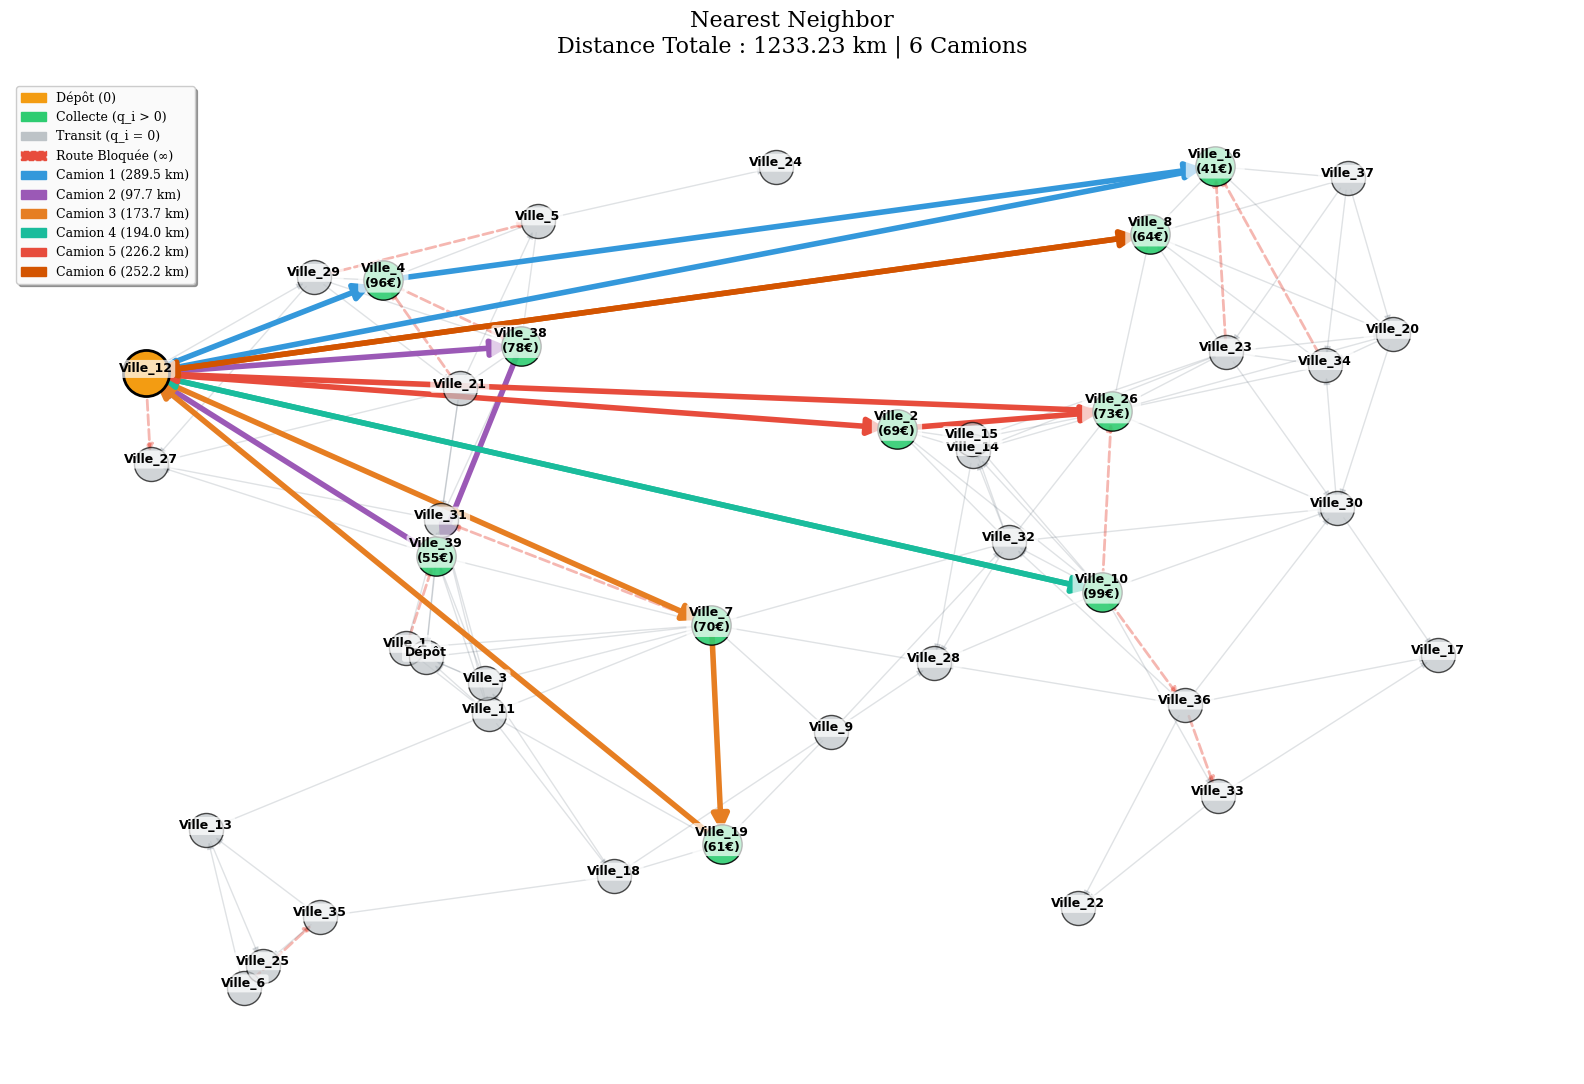

In [72]:
# ── Nearest Neighbor Test ─────────────────────────────────────────────────────
import time
t0 = time.time()
sol_nn = nearest_neighbor_vrp(vN_test, mp_test, vd_test, Q=Q_TEST)
t_nn   = time.time() - t0
d_nn   = calculate_total_distance(sol_nn, dr_test)

print(f"Nearest Neighbor  : distance={d_nn:.1f}  trucks={len(sol_nn)}  time={t_nn:.3f}s")
visualize_final_vrp(vN_test, mp_test, vd_test, sol_nn, title="Nearest Neighbor")

## 8.2 Clarke & Wright

Clarke & Wright   : distance=1003.4  trucks=6  time=0.006s
Gain vs NN        : +18.6%


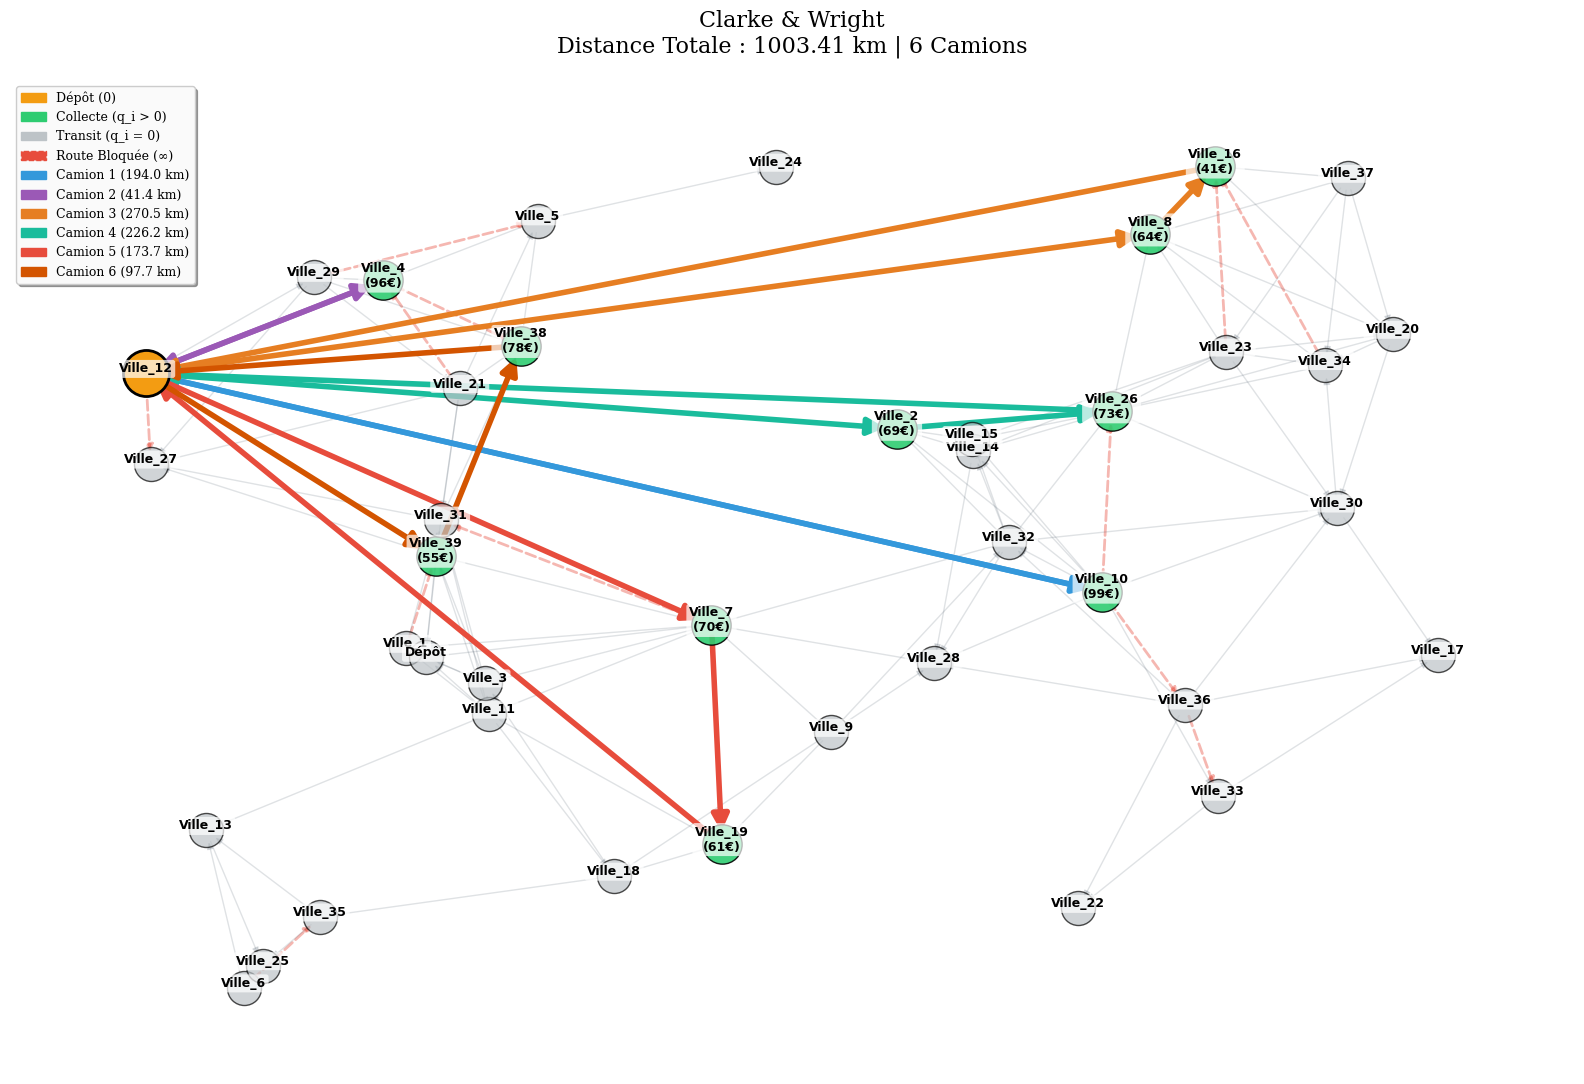

In [74]:
# ── Clarke & Wright Test ──────────────────────────────────────────────────────
import time
t0 = time.time()
sol_cw  = clarke_wright(vN_test, mp_test, vd_test, Q=Q_TEST)   # returns logical directly
t_cw    = time.time() - t0
d_cw    = calculate_total_distance(sol_cw, dr_test)

print(f"Clarke & Wright   : distance={d_cw:.1f}  trucks={len(sol_cw)}  time={t_cw:.3f}s")
print(f"Gain vs NN        : {(d_nn - d_cw)/d_nn*100:+.1f}%")
visualize_final_vrp(vN_test, mp_test, vd_test, sol_cw,
                     title="Clarke & Wright", real_dist=dr_test)

## 8.3 Or-Opt

Or-Opt(CW)        : distance=1003.4  trucks=6  time=0.005s
Gain vs CW        : +0.0%


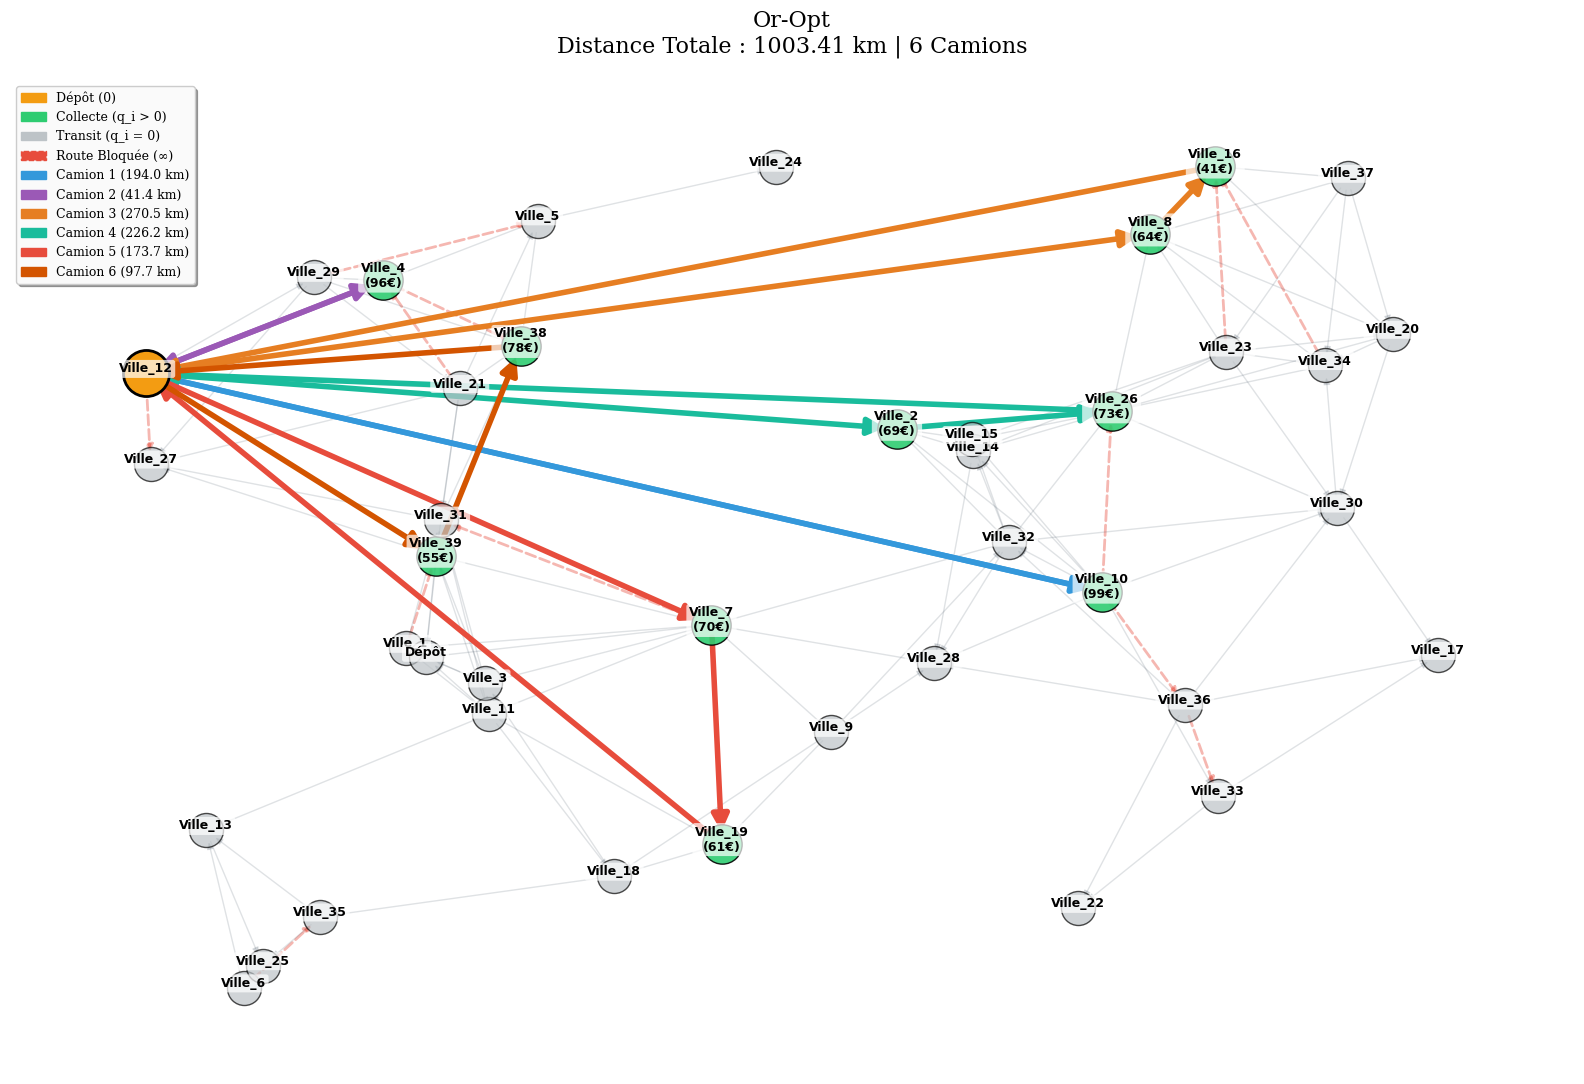

In [75]:
# ── Or-Opt Test (starting from CW) ─────────────────────────────────────────────
t0     = time.time()
sol_or = or_opt(vN_test, mp_test, vd_test, sol_cw, Q=Q_TEST)
t_or   = time.time() - t0
d_or   = calculate_total_distance(sol_or, dr_test)

print(f"Or-Opt(CW)        : distance={d_or:.1f}  trucks={len(sol_or)}  time={t_or:.3f}s")
print(f"Gain vs CW        : {(d_cw - d_or)/d_cw*100:+.1f}%")
visualize_final_vrp(vN_test, mp_test, vd_test, sol_or, title="Or-Opt")

## 8.4 Recuit Simulé v2

Simulated Annealing v2 : distance=1003.4  trucks=6  time=1.979s
Gain vs CW             : +0.0%


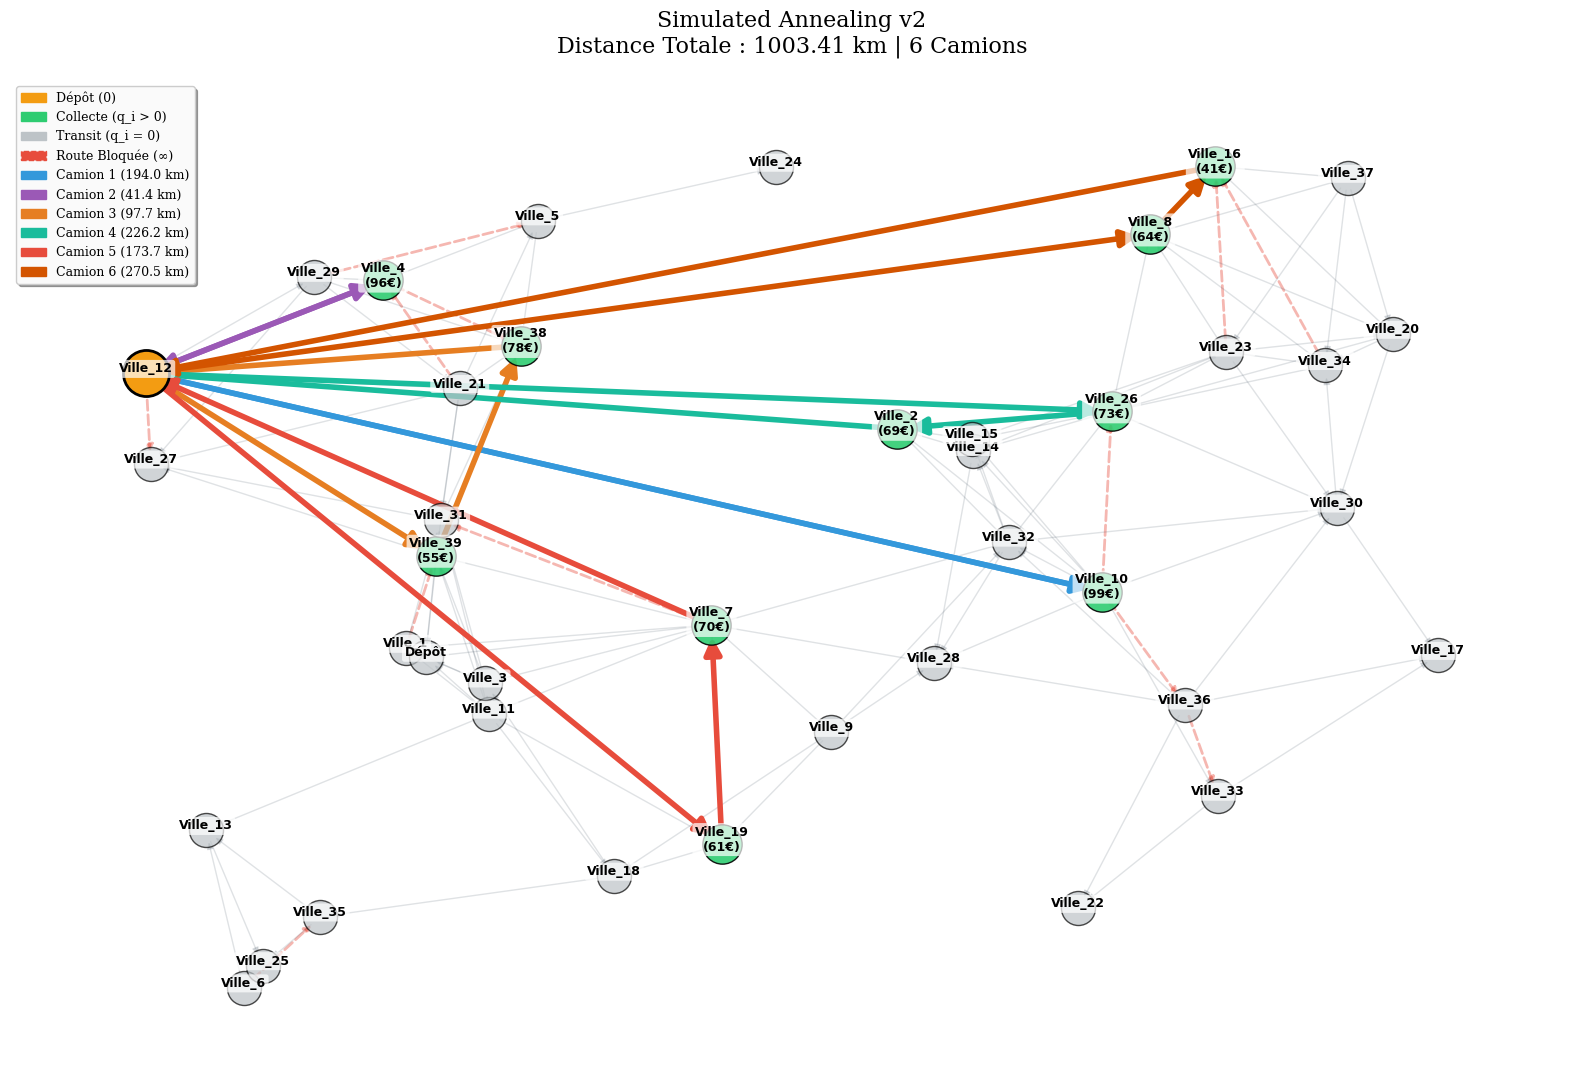

In [ ]:
# ── Simulated Annealing v2 Test (starting from CW) ───────────────────────────────────
t0     = time.time()
sol_re = simulated_annealing(vN_test, mp_test, vd_test, sol_cw, Q=Q_TEST)
t_re   = time.time() - t0
d_re   = calculate_total_distance(sol_re, dr_test)

print(f"Simulated Annealing v2 : distance={d_re:.1f}  trucks={len(sol_re)}  time={t_re:.3f}s")
print(f"Gain vs CW             : {(d_cw - d_re)/d_cw*100:+.1f}%")
visualize_final_vrp(vN_test, mp_test, vd_test, sol_re, title="Simulated Annealing v2")

## 8.5 Récapitulatif

In [82]:
# ── Test Instance Summary ──────────────────────────────────────
import pandas as pd
algo_results = [
    ('Nearest Neighbor', d_nn, len(sol_nn), t_nn),
    ('Clarke & Wright',  d_cw, len(sol_cw), t_cw),
    ('Or-Opt(CW)',       d_or, len(sol_or), t_or),
    ('SA v2(CW)',        d_re, len(sol_re), t_re),
]
df_results = pd.DataFrame(algo_results, columns=['Algorithm', 'Distance', 'Trucks', 'Time (s)'])
df_results['Gain vs NN (%)'] = [(d_nn - d)/d_nn*100 for _, d, _, _ in algo_results]
df_results['Gain vs CW (%)'] = [(d_cw - d)/d_cw*100 for _, d, _, _ in algo_results]
df_results = df_results.round(2)
display(df_results)

,Algorithm,Distance,Trucks,Time (s),Gain vs NN (%),Gain vs CW (%)
0,Nearest Neighbor,1233.23,6,0.00,0.00,-22.9
1,Clarke & Wright,1003.41,6,0.01,18.64,0.0
2,Or-Opt(CW),1003.41,6,0.00,18.64,0.0
3,SA v2(CW),1003.41,6,1.98,18.64,0.0


In [83]:
# ── Verification of all solutions on the test instance ───────────────
print("Checking solution feasibility (logical routes)\n")

display_verification(sol_nn, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Nearest Neighbor')

display_verification(sol_cw, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Clarke & Wright')

display_verification(sol_or, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Or-Opt')

display_verification(sol_re, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Simulated Annealing v2')

Checking solution feasibility (logical routes)

  Nearest Neighbor               ✅ VALID
  Clarke & Wright                ✅ VALID
  Or-Opt                         ✅ VALID
  Simulated Annealing v2         ✅ VALID


True

---
# 9. Benchmarks

Comparaison systématique sur une **grille N × Q** (instances denses — 60% clients).

- **N ∈ {20, 30, 50, 75, 100}** — scalabilité
- **Q ∈ {150, 200, 300, 400}** — influence de la capacité
- **5 essais par point** — résultats moyennés

Algorithmes comparés : **NN / CW / Or-Opt(CW) / Recuit(CW)**

In [ ]:
SIZES_N_F  = [20, 30, 50, 75, 100]
SIZES_Q_F  = [150, 200, 300, 400]
CLIENT_RATIO = 0.60
NB_TRIALS_F  = 5

# Results storage
all_rows = []

print(f"Dense benchmark: {CLIENT_RATIO*100:.0f}% clients, "
      f"{len(SIZES_N_F)}×{len(SIZES_Q_F)} points, {NB_TRIALS_F} trials/point")
print("─" * 65)

for N in SIZES_N_F:
    for Q in SIZES_Q_F:
        nb_to_visit = max(3, int(N * CLIENT_RATIO))
        r_nn, r_cw, r_or, r_re = [], [], [], []

        for _ in range(NB_TRIALS_F):
            vb = generate_synthetic_cities(N)
            vN, mp = create_vrp_city_network(N, X=N*3, blocking_rate=0.1, city_list=vb)
            vd = assign_city_data(vN, nb_to_visit=nb_to_visit)
            dr, _ = calculate_all_paths(list(range(N)), mp)
            demands = {idx: q_i for idx, q_i in vd}

            # NN
            sol_nn  = nearest_neighbor_vrp(vN, mp, vd, Q=Q)
            # CW
            sol_phys = clarke_wright(vN, mp, vd, Q=Q)
            sol_cw   = physical_to_logical_routes(sol_phys, demands)
            # Or-Opt(CW)
            sol_or  = or_opt(vN, mp, vd, sol_cw, Q=Q)
            # SA(CW)
            sol_re  = simulated_annealing(vN, mp, vd, sol_cw, Q=Q)

            r_nn.append(calculate_total_distance(sol_nn, dr))
            r_cw.append(calculate_total_distance(sol_cw, dr))
            r_or.append(calculate_total_distance(sol_or, dr))
            r_re.append(calculate_total_distance(sol_re, dr))

        nn_mean  = np.mean(r_nn)
        cw_mean  = np.mean(r_cw)
        all_rows.append({'N': N, 'Q': Q,
                         'NN':               nn_mean,
                         'CW':               cw_mean,
                         'Or-Opt(CW)':       np.mean(r_or),
                         'SA(CW)':           np.mean(r_re),
                         'Gain CW/NN (%)':   (nn_mean - cw_mean) / nn_mean * 100,
                         'Gain Or-Opt/CW (%)': (cw_mean - np.mean(r_or)) / cw_mean * 100,
                         'Gain SA/CW (%)': (cw_mean - np.mean(r_re)) / cw_mean * 100,
                         })
        print(f"  N={N:3d}, Q={Q:3d} | "
              f"CW/NN={all_rows[-1]['Gain CW/NN (%)']:+5.1f}%  "
              f"Or-Opt/CW={all_rows[-1]['Gain Or-Opt/CW (%)']:+5.1f}%  "
              f"SA/CW={all_rows[-1]['Gain SA/CW (%)']:+5.1f}%")

df_final = pd.DataFrame(all_rows)
print("\n✅ Completed")

Dense benchmark: 60% clients, 5×4 points, 5 trials/point
─────────────────────────────────────────────────────────────────
  N= 20, Q=150 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +0.0%
  N= 20, Q=200 | CW/NN=+13.1%  Or-Opt/CW= +0.9%  SA/CW= +0.3%
  N= 20, Q=300 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +0.2%
  N= 20, Q=400 | CW/NN=+21.7%  Or-Opt/CW= +0.1%  SA/CW= +0.7%
  N= 30, Q=150 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +5.2%
  N= 30, Q=200 | CW/NN= +9.8%  Or-Opt/CW= +0.0%  SA/CW= +2.8%
  N= 30, Q=300 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +1.2%
  N= 30, Q=400 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +0.1%
  N= 50, Q=150 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +2.4%
  N= 50, Q=200 | CW/NN=+12.3%  Or-Opt/CW= +0.0%  SA/CW= +0.2%
  N= 50, Q=300 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +0.1%
  N= 50, Q=400 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +0.8%
  N= 75, Q=150 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +2.3%
  N= 75, Q=200 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  SA/CW= +0.0%

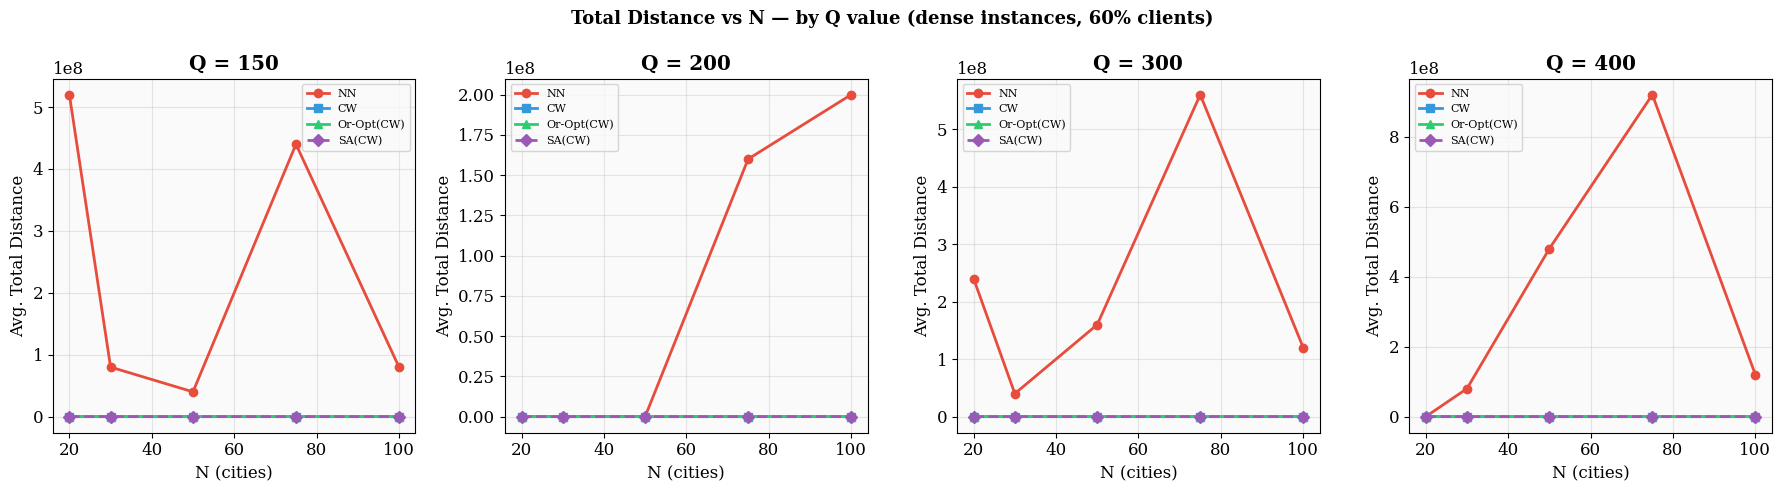

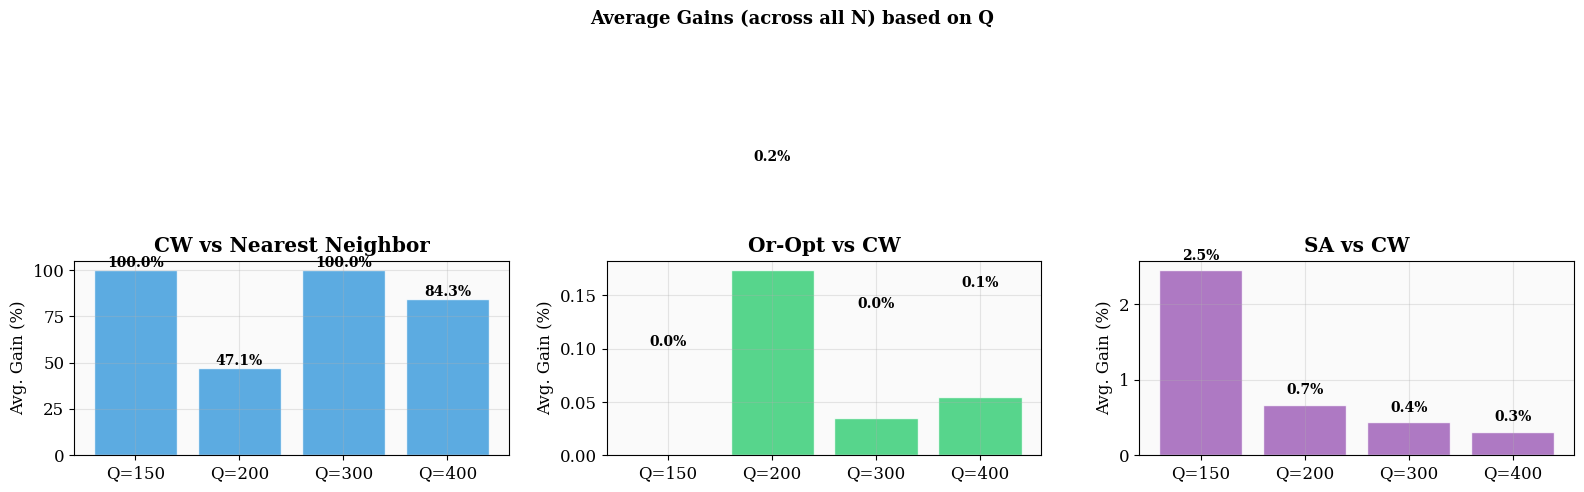

Average gains (all N sizes combined):


,CW improves NN by,Or-Opt improves CW by,SA improves CW by
Q,,,
150,100.0,0.0,2.5
200,47.1,0.2,0.7
300,100.0,0.0,0.4
400,84.3,0.1,0.3


In [85]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ALGOS_COLOR = {
    'NN':         ('#e74c3c', 'o', '-'),
    'CW':         ('#3498db', 's', '-'),
    'Or-Opt(CW)': ('#2ecc71', '^', '-'),
    'SA(CW)':     ('#9b59b6', 'D', '--'),
}

# ── Chart 1: Distance vs N for each Q ─────────────────────────────────
fig, axes = plt.subplots(1, len(SIZES_Q_F), figsize=(18, 5), sharey=False)
fig.suptitle('Total Distance vs N — by Q value (dense instances, 60% clients)',
             fontsize=13, fontweight='bold')

for ax, Q in zip(axes, SIZES_Q_F):
    sub = df_final[df_final['Q'] == Q]
    for algo, (color, marker, ls) in ALGOS_COLOR.items():
        # Ensure the column name matches the one used in the benchmark loop
        column_name = 'SA(CW)' if algo == 'SA(CW)' else algo
        ax.plot(sub['N'], sub[column_name], marker=marker, ls=ls, lw=2,
                color=color, label=algo)
    ax.set_title(f'Q = {Q}', fontweight='bold')
    ax.set_xlabel('N (cities)')
    ax.set_ylabel('Avg. Total Distance')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Chart 2: Gains vs Q (averaged over all N) ────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Average Gains (across all N) based on Q', fontsize=13, fontweight='bold')

gains_by_Q = df_final.groupby('Q')[[
    'Gain CW/NN (%)', 'Gain Or-Opt/CW (%)', 'Gain SA/CW (%)'
]].mean()

for ax, col, color, title in [
    (ax1, 'Gain CW/NN (%)',      '#3498db', 'CW vs Nearest Neighbor'),
    (ax2, 'Gain Or-Opt/CW (%)', '#2ecc71', 'Or-Opt vs CW'),
    (ax3, 'Gain SA/CW (%)',      '#9b59b6', 'SA vs CW'),
]:
    bars = ax.bar(range(len(gains_by_Q)), gains_by_Q[col],
                  color=color, alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(gains_by_Q)))
    ax.set_xticklabels([f'Q={q}' for q in gains_by_Q.index])
    ax.set_ylabel('Avg. Gain (%)')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, gains_by_Q[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ── Summary Table ─────────────────────────────────────────────────────────────
summary = df_final.groupby('Q')[[
    'Gain CW/NN (%)', 'Gain Or-Opt/CW (%)', 'Gain SA/CW (%)'
]].mean().round(1)
summary.columns = ['CW improves NN by', 'Or-Opt improves CW by', 'SA improves CW by']
print("Average gains (all N sizes combined):")
display(summary)

---
# 10. Analyse des paramètres — Recuit Simulé & Or-Opt

## 10.1 Recuit Simulé — paramètres testés

| Paramètre | Rôle | Valeurs testées |
|-----------|------|----------------|
| `T0` | Température initiale — contrôle l'exploration initiale | 50, 200, 500, 1000 |
| `alpha` | Taux de refroidissement — vitesse de convergence | 0.90, 0.95, 0.99, 0.999 |
| `iter_par_T` | Itérations par température — précision à chaque palier | 50, 100, 200, 500 |

## 10.2 Or-Opt — paramètre testé

| Paramètre | Rôle | Valeurs testées |
|-----------|------|----------------|
| `tailles_chaines` | Taille des chaînes de clients déplacées | (1,) (2,) (3,) (1,2) (1,2,3) |

In [ ]:
# ================================================================
# Simulated Annealing — Influence of T0 (Initial Temperature)
# ================================================================
import time, numpy as np, pandas as pd, matplotlib.pyplot as plt

N_PAR, Q_PAR, NB_TRIALS_PAR = 50, 150, 8

def test_instance():
    vb = generate_synthetic_cities(N_PAR)
    vN, mp = create_vrp_city_network(N_PAR, X=N_PAR*3, blocking_rate=0.1, city_list=vb)
    vd = assign_city_data(vN, nb_to_visit=int(N_PAR*0.60))
    dr, _ = calculate_all_paths(list(range(N_PAR)), mp)
    sol_cw = clarke_wright(vN, mp, vd, Q=Q_PAR)
    return vN, mp, vd, dr, sol_cw

VALUES_T0    = [50, 200, 500, 1000, 2000]
VALUES_ALPHA = [0.90, 0.95, 0.99, 0.999]
VALUES_ITER  = [50, 100, 200, 500]

def bench_param(param_name, values, fixed, nb_trials=NB_TRIALS_PAR):
    rows = []
    for val in values:
        dists, times = [], []
        kw = dict(fixed)
        kw[param_name] = val
        for _ in range(nb_trials):
            vN, mp, vd, dr, sol_cw = test_instance()
            t0 = time.time()
            sol = simulated_annealing(vN, mp, vd, sol_cw, Q=Q_PAR, **kw)
            t  = time.time() - t0
            d_cw = calculate_total_distance(sol_cw, dr)
            d    = calculate_total_distance(sol,    dr)
            dists.append(d)
            times.append(t)
        rows.append({
            param_name        : val,
            'Avg. Dist.'      : np.mean(dists),
            'Std. Dist.'      : np.std(dists),
            'Min. Dist.'      : np.min(dists),
            'Avg. Time (s)'   : np.mean(times),
        })
    return pd.DataFrame(rows)

# --- T0 ---
print("Testing T0 (alpha=0.99, iter_per_T=200)...")
df_T0 = bench_param('T0', VALUES_T0, {'alpha': 0.99, 'iter_per_T': 200})

# --- alpha ---
print("Testing alpha (T0=500, iter_per_T=200)...")
df_alpha = bench_param('alpha', VALUES_ALPHA, {'T0': 500, 'iter_per_T': 200})

# --- iter_per_T ---
print("Testing iter_per_T (T0=500, alpha=0.99)...")
df_iter = bench_param('iter_per_T', VALUES_ITER, {'T0': 500, 'alpha': 0.99})

print("\n✅ Benchmarks completed")

Testing T0 (alpha=0.99, iter_per_T=200)...
Testing alpha (T0=500, iter_per_T=200)...
Testing iter_per_T (T0=500, alpha=0.99)...

✅ Benchmarks completed


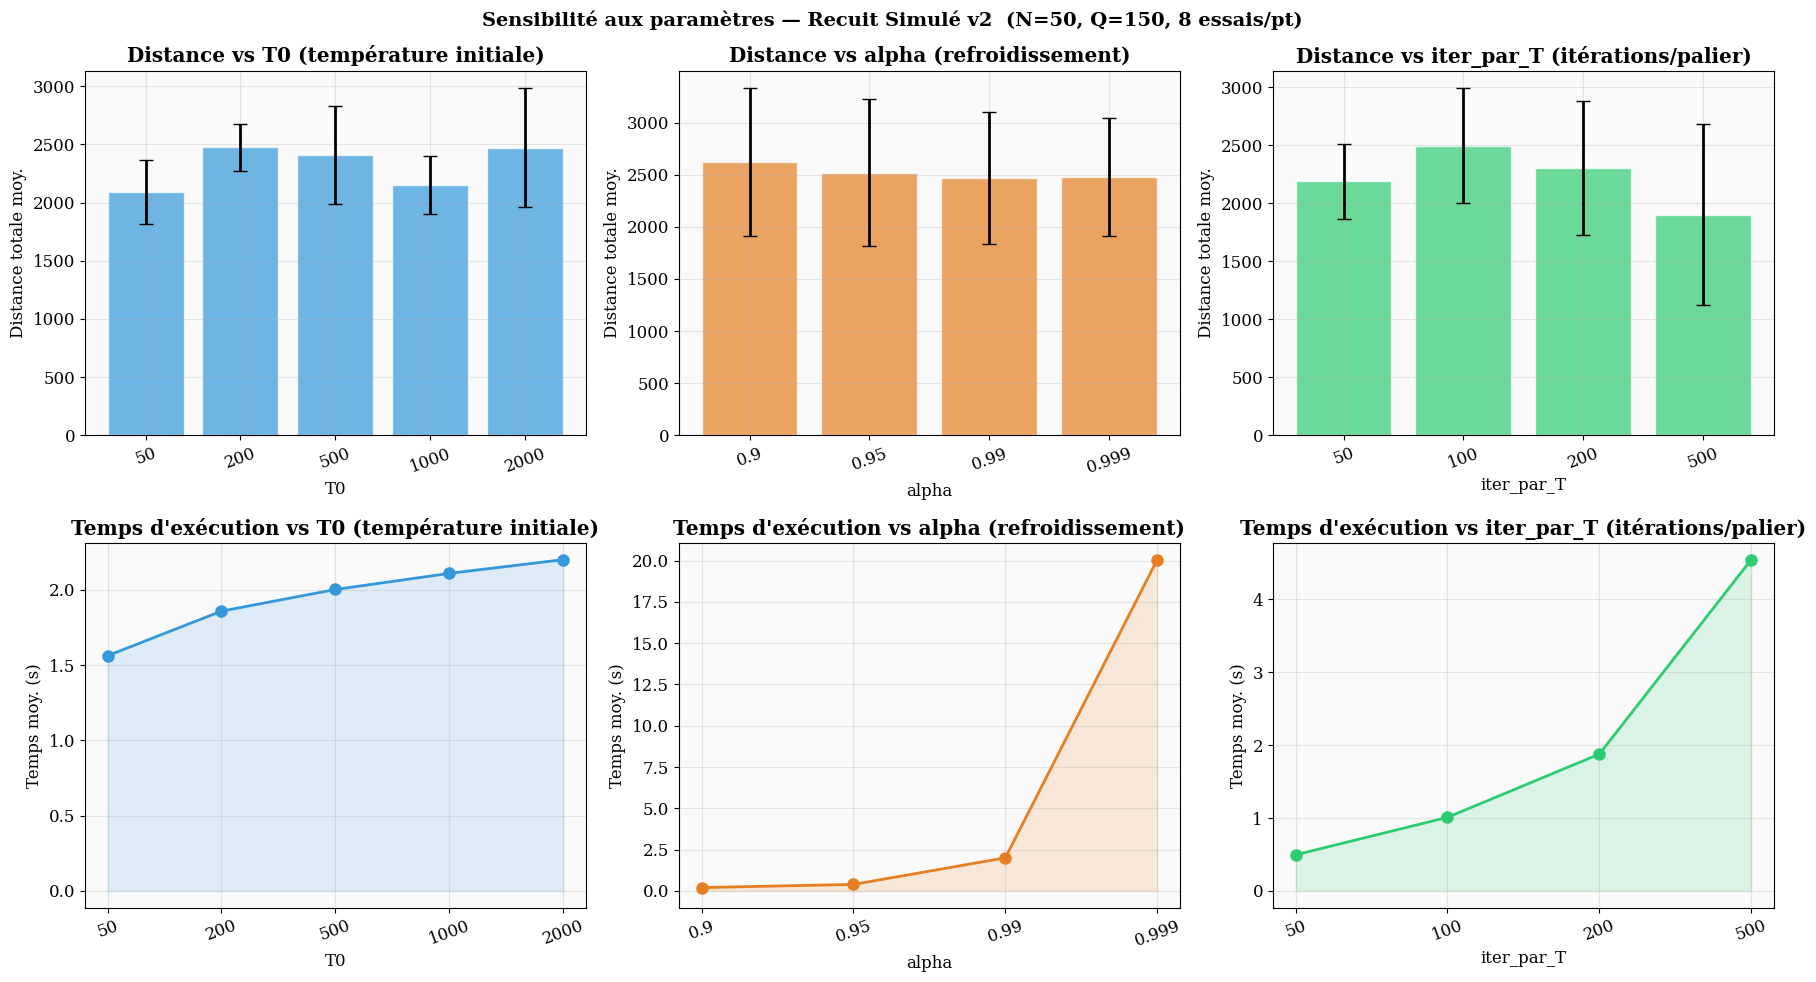


── T0 (température initiale) ──


,Dist. moy.,Dist. std,Dist. min,Temps moy. (s)
T0,,,,
50,2093.203,273.252,1798.031,1.562
200,2474.984,202.464,2249.818,1.858
500,2408.118,418.366,1526.408,2.002
1000,2151.932,249.871,1823.336,2.109
2000,2471.408,511.445,1814.381,2.200



── alpha (refroidissement) ──


,Dist. moy.,Dist. std,Dist. min,Temps moy. (s)
alpha,,,,
0.900,2621.477,708.731,1894.694,0.206
0.950,2520.115,707.308,1774.529,0.397
0.990,2466.840,634.123,1538.007,2.006
0.999,2477.498,568.101,1950.225,20.056



── iter_par_T (itérations/palier) ──


,Dist. moy.,Dist. std,Dist. min,Temps moy. (s)
iter_par_T,,,,
50,2189.243,323.575,1572.495,0.496
100,2495.364,496.608,2062.272,1.009
200,2307.134,577.665,1096.278,1.876
500,1903.088,777.986,65.437,4.541


In [ ]:
# ── Annealing Parameters Visualization ────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Parameter Sensitivity — Simulated Annealing v2 (N={N_PAR}, Q={Q_PAR}, {NB_TRIALS_PAR} trials/pt)',
             fontsize=14, fontweight='bold')

datasets = [
    (df_T0,    'T0',          'T0 (Initial Temperature)',     '#3498db'),
    (df_alpha, 'alpha',       'alpha (Cooling Rate)',         '#e67e22'),
    (df_iter,  'iter_per_T',  'iter_per_T (Iterations/Tier)', '#2ecc71'),
]

for col, (df, param, label, color) in enumerate(datasets):
    x = df[param].astype(str)
    ax_d = axes[0, col]
    ax_d.bar(x, df['Avg. Dist.'], color=color, alpha=0.7, edgecolor='white')
    ax_d.errorbar(range(len(x)), df['Avg. Dist.'], yerr=df['Std. Dist.'],
                  fmt='none', color='black', capsize=5, lw=2)
    ax_d.set_title(f'Distance vs {label}', fontweight='bold')
    ax_d.set_xlabel(param)
    ax_d.set_ylabel('Avg. Total Distance')
    ax_d.set_xticks(range(len(x)))
    ax_d.set_xticklabels(x, rotation=20)
    ax_d.grid(True, alpha=0.3, axis='y')

    ax_t = axes[1, col]
    ax_t.plot(range(len(x)), df['Avg. Time (s)'],
              marker='o', color=color, lw=2, markersize=8)
    ax_t.fill_between(range(len(x)), 0, df['Avg. Time (s)'],
                      color=color, alpha=0.15)
    ax_t.set_title(f"Execution Time vs {label}", fontweight='bold')
    ax_t.set_xlabel(param)
    ax_t.set_ylabel("Avg. Time (s)")
    ax_t.set_xticks(range(len(x)))
    ax_t.set_xticklabels(x, rotation=20)
    ax_t.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for df, param, label, _ in datasets:
    print(f"\n── {label} ──")
    display(df.set_index(param).round(3))

Testing Or-Opt — chain_sizes (N=50, Q=150, 8 trials/config)

  k=1 only     : dist=2459.4 ± 553.2  time=0.010s
  k=2 only     : dist=2480.0 ± 898.9  time=0.008s
  k=3 only     : dist=2520.5 ± 668.0  time=0.009s
  k=1,2        : dist=2050.2 ± 395.4  time=0.009s
  k=1,2,3      : dist=2513.3 ± 457.5  time=0.010s


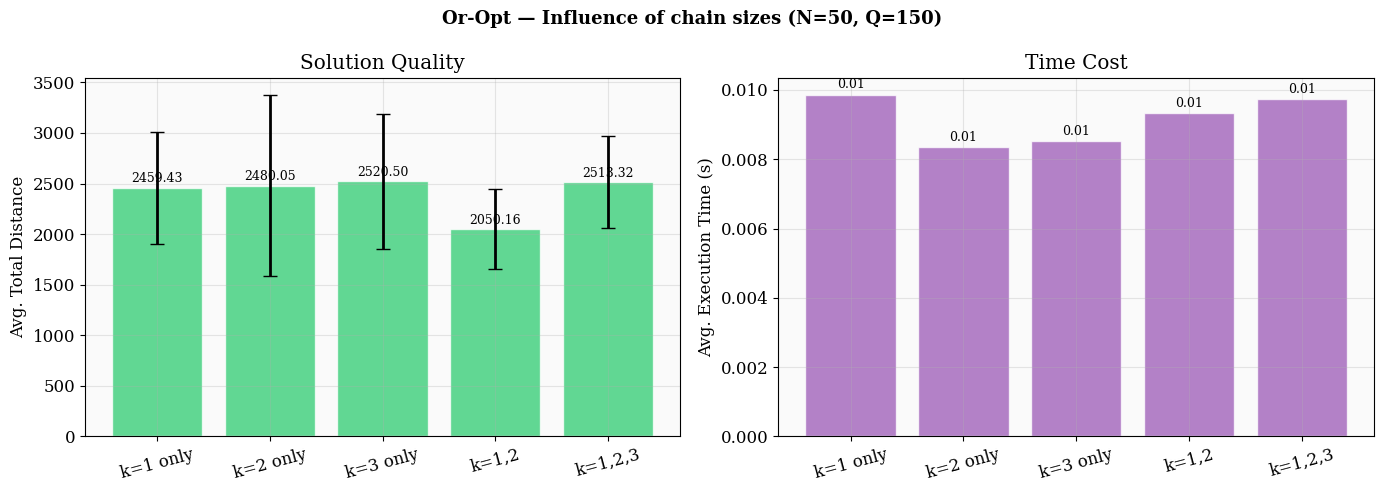

,Chains,Avg. Dist.,Std. Dist.,Min. Dist.,Avg. Time (s)
Config,,,,,
k=1 only,"(1,)",2459.433,553.244,1758.351,0.010
k=2 only,"(2,)",2480.048,898.874,448.504,0.008
k=3 only,"(3,)",2520.503,668.025,2018.364,0.009
"k=1,2","(1, 2)",2050.160,395.368,1484.855,0.009
"k=1,2,3","(1, 2, 3)",2513.316,457.479,1649.414,0.010


In [87]:
# ================================================================
# Or-Opt — Influence of chain_sizes
# ================================================================

CHAIN_CONFIGS = {
    'k=1 only'   : (1,),
    'k=2 only'   : (2,),
    'k=3 only'   : (3,),
    'k=1,2'      : (1, 2),
    'k=1,2,3'    : (1, 2, 3),
}

rows_or = []
print(f"Testing Or-Opt — chain_sizes (N={N_PAR}, Q={Q_PAR}, {NB_TRIALS_PAR} trials/config)\n")

for name, chains in CHAIN_CONFIGS.items():
    dists, times = [], []
    for _ in range(NB_TRIALS_PAR):
        vN, mp, vd, dr, sol_cw = test_instance()
        d_cw = calculate_total_distance(sol_cw, dr)
        t0 = time.time()
        sol_or = or_opt(vN, mp, vd, sol_cw, Q=Q_PAR, chain_sizes=chains)
        t = time.time() - t0
        d = calculate_total_distance(sol_or, dr)
        dists.append(d)
        times.append(t)
        
    rows_or.append({
        'Config'         : name,
        'Chains'         : str(chains),
        'Avg. Dist.'     : np.mean(dists),
        'Std. Dist.'     : np.std(dists),
        'Min. Dist.'     : np.min(dists),
        'Avg. Time (s)'  : np.mean(times),
    })
    print(f"  {name:12s} : dist={np.mean(dists):.1f} ± {np.std(dists):.1f}  time={np.mean(times):.3f}s")

df_or = pd.DataFrame(rows_or)

# Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Or-Opt — Influence of chain sizes (N={N_PAR}, Q={Q_PAR})',
             fontsize=13, fontweight='bold')

x = range(len(df_or))
labels = df_or['Config']

ax1.bar(x, df_or['Avg. Dist.'], color='#2ecc71', alpha=0.75, edgecolor='white')
ax1.errorbar(x, df_or['Avg. Dist.'], yerr=df_or['Std. Dist.'],
             fmt='none', color='black', capsize=5, lw=2)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15)
ax1.set_ylabel('Avg. Total Distance')
ax1.set_title('Solution Quality')
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(x, df_or['Avg. Time (s)'], color='#9b59b6', alpha=0.75, edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15)
ax2.set_ylabel("Avg. Execution Time (s)")
ax2.set_title("Time Cost")
ax2.grid(True, alpha=0.3, axis='y')

for ax in (ax1, ax2):
    for bar_x, val in zip(x, df_or['Avg. Time (s)'] if ax == ax2 else df_or['Avg. Dist.']):
        ax.text(bar_x, val * 1.01, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

display(df_or.set_index('Config').round(3))

In [ ]:
# ── Selected Optimal Parameters ───────────────────────────────────────────────
import pandas as pd

# For each Annealing parameter: best distance/time trade-off
def best_tradeoff(df, param_col):
    """Score = normalized_dist + normalized_time — we minimize both."""
    d = (df['Avg. Dist.'] - df['Avg. Dist.'].min()) / (df['Avg. Dist.'].max() - df['Avg. Dist.'].min() + 1e-9)
    t = (df['Avg. Time (s)'] - df['Avg. Time (s)'].min()) / (df['Avg. Time (s)'].max() - df['Avg. Time (s)'].min() + 1e-9)
    score = 0.7 * d + 0.3 * t   # quality is prioritized (70%)
    best_idx = score.idxmin()
    return df.loc[best_idx, param_col], score[best_idx]

best_T0,    sc_T0    = best_tradeoff(df_T0,    'T0')
best_alpha, sc_alpha = best_tradeoff(df_alpha, 'alpha')
best_iter,  sc_iter  = best_tradeoff(df_iter,  'iter_per_T')

# Best configuration for Or-Opt
or_scores = (0.7 * (df_or['Avg. Dist.'] - df_or['Avg. Dist.'].min()) / (df_or['Avg. Dist.'].max() - df_or['Avg. Dist.'].min() + 1e-9) + 
             0.3 * (df_or['Avg. Time (s)'] - df_or['Avg. Time (s)'].min()) / (df_or['Avg. Time (s)'].max() - df_or['Avg. Time (s)'].min() + 1e-9))
best_chain = df_or.loc[or_scores.idxmin(), 'Config']

print("╔══════════════════════════════════════════════════════════╗")
print("║               Selected Optimal Parameters                ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Simulated Annealing v2                                 ║")
print(f"║    T0           : {best_T0:<10}  (best dist/time tradeoff)  ║")
print(f"║    alpha        : {best_alpha:<10}  (best dist/time tradeoff)  ║")
print(f"║    iter_per_T   : {best_iter:<10}  (best dist/time tradeoff)  ║")
print(f"║  Or-Opt                                                 ║")
print(f"║    chain_sizes  : {best_chain:<35} ║")
print("╚══════════════════════════════════════════════════════════╝")

print(f"\nConfirmation — Annealing with optimal parameters vs CW over {NB_TRIALS_PAR} trials:")
opt_gains = []
for _ in range(NB_TRIALS_PAR):
    vN, mp, vd, dr, sol_cw = test_instance()
    d_cw = calculate_total_distance(sol_cw, dr)
    sol_opt = simulated_annealing(vN, mp, vd, sol_cw, Q=Q_PAR,
                                     T0=best_T0, alpha=best_alpha, iter_per_T=best_iter)
    d_opt = calculate_total_distance(sol_opt, dr)
    opt_gains.append((d_cw - d_opt) / d_cw * 100)

print(f"  Avg. gain vs CW: {np.mean(opt_gains):+.2f}% ± {np.std(opt_gains):.2f}%")

╔══════════════════════════════════════════════════════════╗
║               Selected Optimal Parameters                ║
╠══════════════════════════════════════════════════════════╣
║  Simulated Annealing v2                                 ║
║    T0           : 500         (best dist/time tradeoff)  ║
║    alpha        : 0.95        (best dist/time tradeoff)  ║
║    iter_per_T   : 200         (best dist/time tradeoff)  ║
║  Or-Opt                                                 ║
║    chain_sizes  : k=1,2                               ║
╚══════════════════════════════════════════════════════════╝

Confirmation — Annealing with optimal parameters vs CW over 8 trials:
  Avg. gain vs CW: +1.35% ± 2.38%
